# Convolutional Autoencoders

In this notebook, we build a convolutional autoencoder and use it to find defective Bottle images. The model learns from normal images only. At evaluation time, a large reconstruction error would suggest that an image may contain a defect.

## 1. Goal and starting choices

**Question.** Can a convolutional autoencoder trained only on normal Bottle images rank defective test images above normal test images using reconstruction error?

We use `bottle` so we can compare the autoencoder with our existing frozen ResNet-18 + 5-NN baseline. The images are well aligned, which makes Bottle a reasonable category for our first autoencoder.

We resize the colour images to 256 x 256 so training remains manageable. This removes some detail from the original 900 x 900 images, so very small defects may become harder to detect. We first check whether the model reconstructs normal validation images well, and later compare defect-detection results with the baseline.

### AE-01 starting settings

These are practical starting settings rather than claimed best values. We keep a record of later changes so the learning process is visible.

| Setting | AE-01 value | Why we chose it |
| --- | --- | --- |
| Image size | 256 x 256 | Keeps useful detail while remaining manageable on our GPU. |
| Batch size | 16 | Fits comfortably in GPU memory and gives several updates per epoch. |
| Data loading | 2 workers; pinned memory on CUDA | Helps prepare images while the GPU is working. |
| Learning rate | 1e-3 with Adam | A common starting value for Adam. |
| Maximum epochs | 30 | A short first run that shows whether the model is learning. |
| Threshold percentile | 95th | Marks images above most normal validation scores as possible defects. |


In [59]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from anomaly_detection import MVTecImageDataset, build_mvtec_manifest

SEED = 17
IMAGE_SIZE = 256
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
THRESHOLD_PERCENTILE = 95
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 2
PIN_MEMORY = DEVICE.type == 'cuda'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'Using {DEVICE} with {NUM_WORKERS} data-loader workers')


Using cuda with 2 data-loader workers


In [60]:
# Reduce image sizes -> reduce notebook size
plt.rcParams['figure.dpi'] = 72
plt.rcParams['savefig.dpi'] = 72

## 2. Data split

MVTec provides 209 normal Bottle training images. We split them into 167 training images and 42 validation images, using the same seed as the baseline notebook. We use validation images to follow training and calculate thresholds. The test images are used later to see how well the completed models detect defects.


In [61]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
data_path = project_root / 'data/mvtec'
manifest = build_mvtec_manifest(data_path)
bottle_train = manifest.query("product == 'bottle' and split == 'train' and not is_anomaly").reset_index(drop=True)
bottle_test = manifest.query("product == 'bottle' and split == 'test'").reset_index(drop=True)

train_df, validation_df = train_test_split(bottle_train, test_size=0.2, random_state=SEED)
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

print(f'Normal training images: {len(train_df)}')
print(f'Normal validation images: {len(validation_df)}')
print(f'Bottle test images: {len(bottle_test)}')


Normal training images: 167
Normal validation images: 42
Bottle test images: 83


### Saved model checkpoints

Long-running standalone experiments save their selected model in the project `models/` directory. Their `RETRAIN_...` flag defaults to `False`: an existing checkpoint is loaded, a missing checkpoint is trained and saved automatically, and setting the flag to `True` deliberately replaces it after retraining. Checkpoints are local generated files and are excluded from Git. Fixed seeds improve repeatability, although exact GPU results can still vary slightly across hardware or library versions. Only load checkpoint files created by this project.


In [62]:
checkpoint_project_root = Path.cwd().resolve()
if checkpoint_project_root.name == 'notebooks':
    checkpoint_project_root = checkpoint_project_root.parent
MODELS_DIR = checkpoint_project_root / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

def save_model_checkpoint(checkpoint_path, model_to_save, metadata):
    """Save CPU model weights plus small experiment metadata."""
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    cpu_state = {
        key: value.detach().cpu().clone()
        for key, value in model_to_save.state_dict().items()
    }
    torch.save(
        {'model_state_dict': cpu_state, 'metadata': metadata},
        checkpoint_path,
    )
    print(f'Saved checkpoint: {checkpoint_path}')

def load_model_checkpoint(checkpoint_path, model_to_load, expected_experiment):
    """Load a local checkpoint and verify its experiment name."""
    checkpoint_path = Path(checkpoint_path)
    checkpoint = torch.load(
        checkpoint_path, map_location=DEVICE, weights_only=False
    )
    metadata = checkpoint.get('metadata', {})
    if metadata.get('experiment') != expected_experiment:
        raise ValueError(
            f'Checkpoint {checkpoint_path} belongs to '
            f"{metadata.get('experiment')!r}, not {expected_experiment!r}."
        )
    model_to_load.load_state_dict(checkpoint['model_state_dict'])
    model_to_load.to(DEVICE)
    model_to_load.eval()
    print(f'Loaded checkpoint: {checkpoint_path}')
    return metadata

print(f'Model checkpoints directory: {MODELS_DIR}')


Model checkpoints directory: /home/ali/projects/anomaly-detection/models


In [63]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),  # Scales pixels to [0.0, 1.0]
])

# MVTecImageDataset returns (image_tensor, anomaly_label, path) for each manifest row.
train_dataset = MVTecImageDataset(train_df, transform=image_transform)
validation_dataset = MVTecImageDataset(validation_df, transform=image_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)


## 3. Starting autoencoder architecture

We chose a simple, computationally manageable reference architecture with three stride-2 convolutional stages. These reduce the spatial resolution gradually from 256 x 256 to 32 x 32, while the channel progression `32 -> 64 -> 128` allows the encoder to represent more feature types as spatial detail decreases. The resulting `128 x 32 x 32` bottleneck retains spatial information about the aligned Bottle structure, and a symmetric transposed-convolution decoder restores the image to its original size. We use mean-squared reconstruction error (MSE) because it directly measures pixelwise reconstruction differences.

### Reading one convolution layer

`nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)` describes how a layer converts one image-like tensor into another. `in_channels` is the number of input feature maps; for an RGB image it is 3 (red, green, and blue). `out_channels` is the number of learned filters and therefore the number of output feature maps. These maps are not separate images: each map records where one learned visual pattern is active.

The `kernel_size=4` means each filter examines a 4 x 4 local patch. `stride=2` moves the filter two pixels at a time, halving an even image size. `padding=1` adds a one-pixel border so the sizes work cleanly. For the encoder, the output-size formula is `floor((input - kernel + 2 * padding) / stride) + 1`; with 256, 4, 1, and 2 this gives 128.

| Layer | Input channels | Output channels | Spatial size | Why this choice in AE-01 |
| --- | ---: | ---: | --- | --- |
| Input | 3 | — | 256 x 256 | RGB Bottle image. |
| Encoder 1 | 3 | 32 | 256 x 256 -> 128 x 128 | Learn simple local patterns while beginning spatial compression. |
| Encoder 2 | 32 | 64 | 128 x 128 -> 64 x 64 | Keep more types of learned patterns as spatial detail is reduced. |
| Encoder 3 | 64 | 128 | 64 x 64 -> 32 x 32 | Create the latent feature maps used by the decoder. |

We chose `4 x 4`, stride 2, padding 1 because its transposed-convolution counterpart doubles the spatial size exactly: 32 -> 64 -> 128 -> 256. A `3 x 3`, stride 1 convolution is also common, but it preserves spatial size and would need a separate pooling or downsampling operation. Neither choice is universally better; the current configuration is a simple, symmetric first experiment.

### What this architecture comparison can tell us

This is a simple starting architecture, not a proven best design. AE-01 to AE-04 reuse it while we learn about training duration and learning rate. AE-05 reuses it with a different training task. Later experiments try a smaller `16 x 16` representation.


In [64]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = ConvAutoencoder().to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'Trainable parameters: {parameter_count:,}')


ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)
Trainable parameters: 331,075


In [65]:
sample_images, _, _ = next(iter(validation_loader))
with torch.inference_mode():
    sample_reconstruction = model(sample_images.to(DEVICE, non_blocking=PIN_MEMORY))

assert sample_reconstruction.shape == sample_images.shape
print(f'Input shape:  {tuple(sample_images.shape)}')
print(f'Output shape: {tuple(sample_reconstruction.shape)}')

Input shape:  (16, 3, 256, 256)
Output shape: (16, 3, 256, 256)


## 4. Training experiment AE-01

We train only on normal images and select the epoch with the lowest normal-validation MSE. We record both curves so we can stop or revise the experiment if validation loss stops improving while training loss continues to fall.


In [66]:
criterion = nn.MSELoss()

In [67]:
def clean_reconstruction_scores(model_to_score, loader):
    """Return per-image clean-input MSE scores, labels, and paths."""
    model_to_score.eval()
    scores, labels, paths = [], [], []
    with torch.inference_mode():
        for images, batch_labels, batch_paths in loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            reconstructions = model_to_score(images)
            image_scores = (images - reconstructions).square().mean(dim=(1, 2, 3))
            scores.extend(image_scores.cpu().numpy())
            labels.extend(batch_labels.numpy())
            paths.extend(batch_paths)
    return np.asarray(scores), np.asarray(labels), paths


In [68]:
criterion = nn.MSELoss()
RETRAIN_AE01_TO_AE04 = False  # True retrains and replaces the full chain.
STANDARD_CHECKPOINT_PATHS = {
    'AE-01': MODELS_DIR / 'ae01_clean_reconstruction.pt',
    'AE-02': MODELS_DIR / 'ae02_clean_continuation.pt',
    'AE-03': MODELS_DIR / 'ae03_clean_continuation.pt',
    'AE-04': MODELS_DIR / 'ae04_clean_lower_lr.pt',
}
load_standard_checkpoints = (
    not RETRAIN_AE01_TO_AE04
    and all(path.exists() for path in STANDARD_CHECKPOINT_PATHS.values())
)
if load_standard_checkpoints:
    print('Loading saved AE-01 to AE-04 checkpoints; training loops will be skipped.')
else:
    print('Training the full AE-01 to AE-04 trajectory.')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {'train_loss': [], 'validation_loss': []}
best_state, best_optimizer_state = None, None
best_validation_loss = float('inf')
if load_standard_checkpoints:
    metadata_ae01 = load_model_checkpoint(
        STANDARD_CHECKPOINT_PATHS['AE-01'], model, expected_experiment='AE-01'
    )
    history = metadata_ae01['history']
    best_validation_loss = metadata_ae01['best_validation_loss']
    best_state = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }
    best_optimizer_state = copy.deepcopy(optimizer.state_dict())

for epoch in (range(1, MAX_EPOCHS + 1) if not load_standard_checkpoints else []):
    model.train() # switch the model into training mode
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY) # Move image tensors to the GPU
        optimizer.zero_grad() # clear previous gradients
        loss = criterion(model(images), images) # model(images) if the forward pass, i.e. predict, calculate loss (mse)
        loss.backward() # runs backpropagation, calculates gradients
        optimizer.step() # update filter weights using Adam and the gradients
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model.eval() # switch the model to evaluation mode (prediction mode)
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    history['train_loss'].append(train_loss)
    history['validation_loss'].append(validation_loss)
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        best_optimizer_state = copy.deepcopy(optimizer.state_dict())
    print(f'Epoch {epoch:02d}: train={train_loss:.6f}, validation={validation_loss:.6f}')

model.load_state_dict(best_state)
optimizer.load_state_dict(best_optimizer_state)
print(f'Best validation MSE: {best_validation_loss:.6f}')


Loading saved AE-01 to AE-04 checkpoints; training loops will be skipped.
Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae01_clean_reconstruction.pt
Best validation MSE: 0.001073


In [69]:
def show_reconstructions(model_to_visualise, loader, count=5, experiment_name='Autoencoder'):
    """Display matching input, reconstruction, and error-map columns for one model."""
    model_to_visualise.eval()
    images, _, _ = next(iter(loader))
    with torch.inference_mode():
        reconstructions = model_to_visualise(images.to(DEVICE, non_blocking=PIN_MEMORY)).cpu()
    fig, axes = plt.subplots(3, count, figsize=(3 * count, 8))
    for column in range(count):
        difference = (images[column] - reconstructions[column]).abs().mean(dim=0)
        axes[0, column].imshow(images[column].permute(1, 2, 0))
        axes[0, column].set_title('Input')
        axes[1, column].imshow(reconstructions[column].permute(1, 2, 0))
        axes[1, column].set_title('Reconstruction')
        axes[2, column].imshow(difference, cmap='magma')
        axes[2, column].set_title('Mean abs. difference (visual only)')
        for row in range(3): 
            axes[row, column].axis('off')
    fig.suptitle(f'{experiment_name}: normal validation reconstructions', y=1.02)
    plt.tight_layout()

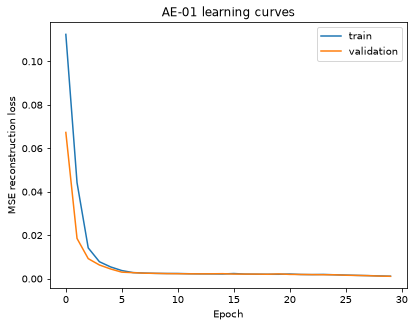

In [111]:
plt.plot(history['train_loss'], label='train')
plt.plot(history['validation_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('AE-01 learning curves')
plt.legend()
plt.show()


# Uncomment this to see samples of reconstructions
# show_reconstructions(model, validation_loader, experiment_name='AE-01')


### Inspecting the latent space

Run the following cell after training. It passes one normal validation image through the encoder only, so we can inspect the latent tensor before the decoder reconstructs it. The `128 x 32 x 32` result means 128 learned activation maps, each with a 32 x 32 spatial layout. A bright or dark area is an activation value, not a defect label; individual maps often have no simple human name. Their value is that, together, they provide the representation the decoder must use to rebuild a normal Bottle image.

The error maps above use mean absolute difference because it is easy to see. Our anomaly score and training loss use MSE, so the colour in an error map is not the score used for thresholding.


In [71]:
def show_latent_space(model_to_visualise, loader, channels_to_show=16, experiment_name='Autoencoder'):
    model_to_visualise.eval()
    images, _, _ = next(iter(loader))
    with torch.inference_mode():
        latent = model_to_visualise.encoder(images[:1].to(DEVICE, non_blocking=PIN_MEMORY)).cpu()

    input_values = images[0].numel()
    latent_values = latent[0].numel()
    print(f'Input shape:  {tuple(images[:1].shape)} ({input_values:,} values)')
    print(f'Latent shape: {tuple(latent.shape)} ({latent_values:,} values)')
    print(f'Value-count compression: {input_values / latent_values:.2f}x')

    columns = 4
    rows = (channels_to_show + columns - 1) // columns
    figure, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
    for channel, axis in enumerate(axes.flat):
        if channel < channels_to_show:
            axis.imshow(latent[0, channel], cmap='viridis')
            axis.set_title(f'Latent feature map {channel}')
        axis.axis('off')
    figure.suptitle(f'{experiment_name}: first {channels_to_show} latent feature maps for one normal validation image')
    plt.tight_layout()

In [112]:

# Uncomment to see latent space sample
# show_latent_space(model, validation_loader, experiment_name='AE-01')


## 4.1 AE-02: continue training to 100 epochs

AE-01's validation loss was still decreasing at epoch 30, so we continue the same model to 100 epochs. The architecture, data split, loss, learning rate, and batch size remain the same. This lets us see whether the model simply needed more time.

We keep `BATCH_SIZE = 16`. Although a larger batch might use more of the GPU, it would also change the number of model updates per epoch and could change learning behaviour.

We keep the epoch with the lowest validation MSE. An earlier independent 60-epoch restart is also kept in the experiment log, but it is not directly comparable because it began from new random weights.


Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae02_clean_continuation.pt
AE-02 best epoch: 97
AE-02 best validation MSE: 0.000465


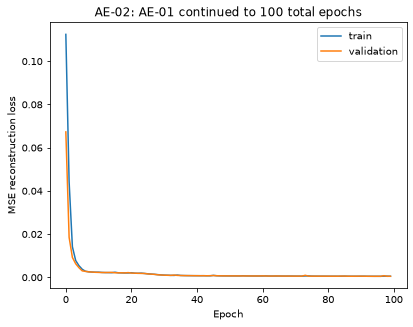

In [73]:
AE02_MAX_EPOCHS = 100

# Preserve the epoch-30 AE-01 model for fair visual and score comparisons.
model_ae01 = copy.deepcopy(model).to(DEVICE)

# Continue the same model, optimiser, and shuffled loader from epoch 31.
history_ae02 = {key: values.copy() for key, values in history.items()}
best_state_ae02 = {key: value.detach().cpu().clone() for key, value in best_state.items()}
best_optimizer_state_ae02 = copy.deepcopy(best_optimizer_state)
best_validation_loss_ae02 = best_validation_loss
best_epoch_ae02 = int(np.argmin(history_ae02['validation_loss']) + 1)
if load_standard_checkpoints:
    metadata_ae02 = load_model_checkpoint(
        STANDARD_CHECKPOINT_PATHS['AE-02'], model, expected_experiment='AE-02'
    )
    history_ae02 = metadata_ae02['history']
    best_validation_loss_ae02 = metadata_ae02['best_validation_loss']
    best_epoch_ae02 = metadata_ae02['best_epoch']
    best_state_ae02 = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }
    best_optimizer_state_ae02 = copy.deepcopy(optimizer.state_dict())

for epoch in (
    range(MAX_EPOCHS + 1, AE02_MAX_EPOCHS + 1)
    if not load_standard_checkpoints else []
):
    model.train()
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer.zero_grad()
        loss = criterion(model(images), images)
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model.eval()
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    history_ae02['train_loss'].append(train_loss)
    history_ae02['validation_loss'].append(validation_loss)

    if validation_loss < best_validation_loss_ae02:
        best_validation_loss_ae02 = validation_loss
        best_epoch_ae02 = epoch
        best_state_ae02 = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        best_optimizer_state_ae02 = copy.deepcopy(optimizer.state_dict())

    print(f'Epoch {epoch:02d}: train={train_loss:.6f}, validation={validation_loss:.6f}')

final_state_ae02 = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
final_optimizer_state_ae02 = copy.deepcopy(optimizer.state_dict())
model.load_state_dict(best_state_ae02)
optimizer.load_state_dict(best_optimizer_state_ae02)
model_ae02 = copy.deepcopy(model).to(DEVICE)
print(f'AE-02 best epoch: {best_epoch_ae02}')
print(f'AE-02 best validation MSE: {best_validation_loss_ae02:.6f}')

plt.plot(history_ae02['train_loss'], label='train')
plt.plot(history_ae02['validation_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('AE-02: AE-01 continued to 100 total epochs')
plt.legend()
plt.show()


### AE-02 reconstruction review

We use the same helper and the same first normal validation batch as AE-01. Passing `model_ae02` explicitly means the function does not accidentally visualise AE-01. Compare shape boundaries, reflections, and the error maps with the AE-01 figure above.


In [113]:
# Uncomment to see sample reconstructions
# show_reconstructions(model_ae02, validation_loader, experiment_name='AE-02')


## 4.2 AE-03: continue training to 150 epochs

AE-02 reached its best validation MSE at epoch 97, close to the end of the run. We therefore give the same model 50 more epochs to see whether it continues improving.

We resume from epoch 100 and keep the other main settings unchanged. As before, we save the checkpoint with the lowest validation MSE.


Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae03_clean_continuation.pt
AE-03 best epoch: 150
AE-03 best validation MSE: 0.000374


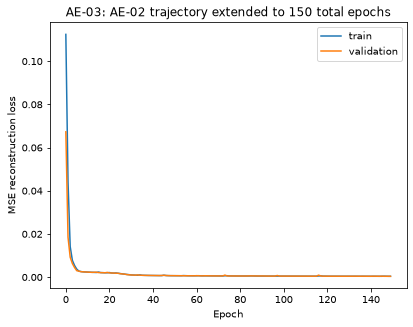

In [114]:
AE03_MAX_EPOCHS = 150

# Resume the exact epoch-100 trajectory, while retaining AE-02's best checkpoint for comparison.
model.load_state_dict(final_state_ae02)
optimizer.load_state_dict(final_optimizer_state_ae02)
history_ae03 = {key: values.copy() for key, values in history_ae02.items()}
best_state_ae03 = {key: value.detach().cpu().clone() for key, value in best_state_ae02.items()}
best_optimizer_state_ae03 = copy.deepcopy(best_optimizer_state_ae02)
best_validation_loss_ae03 = best_validation_loss_ae02
best_epoch_ae03 = best_epoch_ae02
if load_standard_checkpoints:
    metadata_ae03 = load_model_checkpoint(
        STANDARD_CHECKPOINT_PATHS['AE-03'], model, expected_experiment='AE-03'
    )
    history_ae03 = metadata_ae03['history']
    best_validation_loss_ae03 = metadata_ae03['best_validation_loss']
    best_epoch_ae03 = metadata_ae03['best_epoch']
    best_state_ae03 = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }
    best_optimizer_state_ae03 = copy.deepcopy(optimizer.state_dict())

for epoch in (
    range(AE02_MAX_EPOCHS + 1, AE03_MAX_EPOCHS + 1)
    if not load_standard_checkpoints else []
):
    model.train()
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer.zero_grad()
        loss = criterion(model(images), images)
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model.eval()
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    history_ae03['train_loss'].append(train_loss)
    history_ae03['validation_loss'].append(validation_loss)

    if validation_loss < best_validation_loss_ae03:
        best_validation_loss_ae03 = validation_loss
        best_epoch_ae03 = epoch
        best_state_ae03 = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        best_optimizer_state_ae03 = copy.deepcopy(optimizer.state_dict())

    print(f'Epoch {epoch:03d}: train={train_loss:.6f}, validation={validation_loss:.6f}')

# Preserve epoch 150 separately: AE-04 must continue the actual trajectory, not this best checkpoint.
final_state_ae03 = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
final_optimizer_state_ae03 = copy.deepcopy(optimizer.state_dict())

model.load_state_dict(best_state_ae03)
optimizer.load_state_dict(best_optimizer_state_ae03)
model_ae03 = copy.deepcopy(model).to(DEVICE)
print(f'AE-03 best epoch: {best_epoch_ae03}')
print(f'AE-03 best validation MSE: {best_validation_loss_ae03:.6f}')

plt.plot(history_ae03['train_loss'], label='train')
plt.plot(history_ae03['validation_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('AE-03: AE-02 trajectory extended to 150 total epochs')
plt.legend()
plt.show()

# Uncomment to see sample reconstructions
# show_reconstructions(model_ae03, validation_loader, experiment_name='AE-03')


## 4.3 AE-04: continue with a lower learning rate

AE-03 was still improving at epoch 150, but much more slowly. We lower the learning rate so Adam makes smaller updates during the last 50 epochs.

We resume from epoch 150, change the learning rate from `1e-3` to `1e-4`, and train through epoch 200. The other main settings remain the same, and we keep the checkpoint with the lowest validation MSE.


Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae04_clean_lower_lr.pt
AE-04 best epoch: 200
AE-04 best validation MSE: 0.000366


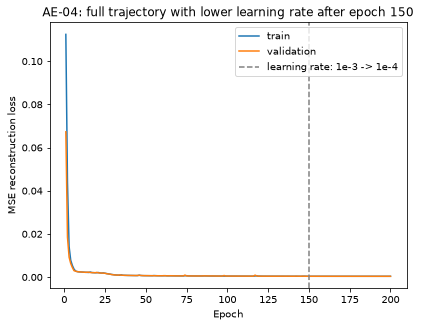

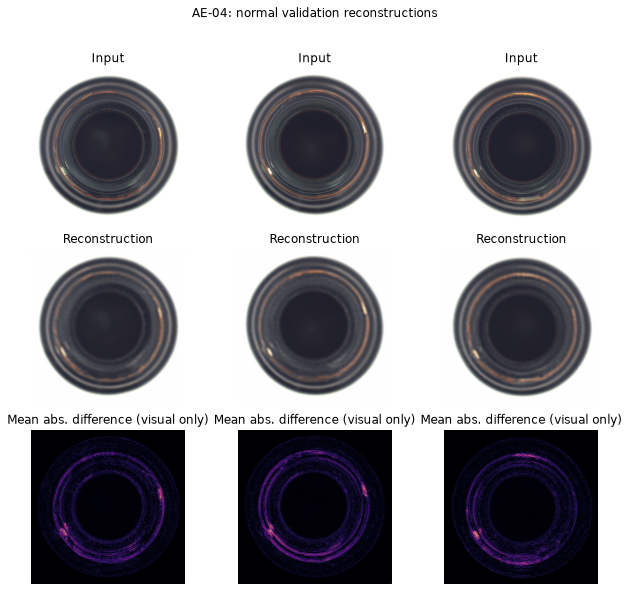

In [117]:
AE04_MAX_EPOCHS = 200
AE04_LEARNING_RATE = 1e-4

# Compatibility for the currently running notebook: the earlier AE-03 cell did not save final_state_ae03.
# This fallback is valid only because AE-03's best epoch was its final epoch (150).
if 'final_state_ae03' not in globals():
    if best_epoch_ae03 != AE03_MAX_EPOCHS:
        raise RuntimeError('Re-run AE-03 first so its final epoch-150 state is available for AE-04.')
    final_state_ae03 = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    final_optimizer_state_ae03 = copy.deepcopy(optimizer.state_dict())

# Resume epoch 150, not AE-03's best checkpoint, so this is a true learning-rate continuation.
model.load_state_dict(final_state_ae03)
optimizer.load_state_dict(final_optimizer_state_ae03)
for parameter_group in optimizer.param_groups:
    parameter_group['lr'] = AE04_LEARNING_RATE

history_ae04 = {key: values.copy() for key, values in history_ae03.items()}
best_state_ae04 = {key: value.detach().cpu().clone() for key, value in best_state_ae03.items()}
best_optimizer_state_ae04 = copy.deepcopy(best_optimizer_state_ae03)
best_validation_loss_ae04 = best_validation_loss_ae03
best_epoch_ae04 = best_epoch_ae03
if load_standard_checkpoints:
    metadata_ae04 = load_model_checkpoint(
        STANDARD_CHECKPOINT_PATHS['AE-04'], model, expected_experiment='AE-04'
    )
    history_ae04 = metadata_ae04['history']
    best_validation_loss_ae04 = metadata_ae04['best_validation_loss']
    best_epoch_ae04 = metadata_ae04['best_epoch']
    best_state_ae04 = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }
    best_optimizer_state_ae04 = copy.deepcopy(optimizer.state_dict())

for epoch in (
    range(AE03_MAX_EPOCHS + 1, AE04_MAX_EPOCHS + 1)
    if not load_standard_checkpoints else []
):
    model.train()
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer.zero_grad()
        loss = criterion(model(images), images)
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model.eval()
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    history_ae04['train_loss'].append(train_loss)
    history_ae04['validation_loss'].append(validation_loss)

    if validation_loss < best_validation_loss_ae04:
        best_validation_loss_ae04 = validation_loss
        best_epoch_ae04 = epoch
        best_state_ae04 = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        best_optimizer_state_ae04 = copy.deepcopy(optimizer.state_dict())

    print(f'Epoch {epoch:03d}: train={train_loss:.6f}, validation={validation_loss:.6f}')

model.load_state_dict(best_state_ae04)
optimizer.load_state_dict(best_optimizer_state_ae04)
model_ae04 = copy.deepcopy(model).to(DEVICE)
print(f'AE-04 best epoch: {best_epoch_ae04}')
print(f'AE-04 best validation MSE: {best_validation_loss_ae04:.6f}')

plt.plot(range(1, AE04_MAX_EPOCHS + 1), history_ae04['train_loss'], label='train')
plt.plot(range(1, AE04_MAX_EPOCHS + 1), history_ae04['validation_loss'], label='validation')
plt.axvline(150, color='grey', linestyle='--', label='learning rate: 1e-3 -> 1e-4')
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('AE-04: full trajectory with lower learning rate after epoch 150')
plt.legend()
plt.show()

show_reconstructions(model_ae04, validation_loader, experiment_name='AE-04', count=3)


In [77]:
# Save all selected stages after a newly trained full trajectory.
if not load_standard_checkpoints:
    standard_checkpoints = [
        {
            'experiment': 'AE-01',
            'path': MODELS_DIR / 'ae01_clean_reconstruction.pt',
            'model': model_ae01,
            'history': history,
            'best_epoch': int(np.argmin(history['validation_loss']) + 1),
            'best_validation_loss': best_validation_loss,
            'config': {
                'architecture': 'ConvAutoencoder', 'seed': SEED,
                'batch_size': BATCH_SIZE, 'max_epochs': MAX_EPOCHS,
                'learning_rate': LEARNING_RATE,
            },
        },
        {
            'experiment': 'AE-02',
            'path': MODELS_DIR / 'ae02_clean_continuation.pt',
            'model': model_ae02,
            'history': history_ae02,
            'best_epoch': best_epoch_ae02,
            'best_validation_loss': best_validation_loss_ae02,
            'config': {
                'architecture': 'ConvAutoencoder', 'seed': SEED,
                'batch_size': BATCH_SIZE, 'max_epochs': AE02_MAX_EPOCHS,
                'learning_rate': LEARNING_RATE,
                'continued_from': 'AE-01',
            },
        },
        {
            'experiment': 'AE-03',
            'path': MODELS_DIR / 'ae03_clean_continuation.pt',
            'model': model_ae03,
            'history': history_ae03,
            'best_epoch': best_epoch_ae03,
            'best_validation_loss': best_validation_loss_ae03,
            'config': {
                'architecture': 'ConvAutoencoder', 'seed': SEED,
                'batch_size': BATCH_SIZE, 'max_epochs': AE03_MAX_EPOCHS,
                'learning_rate': LEARNING_RATE,
                'continued_from': 'AE-02',
            },
        },
        {
            'experiment': 'AE-04',
            'path': MODELS_DIR / 'ae04_clean_lower_lr.pt',
            'model': model_ae04,
            'history': history_ae04,
            'best_epoch': best_epoch_ae04,
            'best_validation_loss': best_validation_loss_ae04,
            'config': {
                'architecture': 'ConvAutoencoder', 'seed': SEED,
                'batch_size': BATCH_SIZE, 'max_epochs': AE04_MAX_EPOCHS,
                'initial_learning_rate': LEARNING_RATE,
                'learning_rate_change_epoch': AE03_MAX_EPOCHS,
                'refinement_learning_rate': AE04_LEARNING_RATE,
                'continued_from': 'AE-03',
            },
        },
    ]
    for checkpoint_spec in standard_checkpoints:
        save_model_checkpoint(
            checkpoint_spec['path'], checkpoint_spec['model'],
            metadata={
                'experiment': checkpoint_spec['experiment'],
                'config': checkpoint_spec['config'],
                'best_epoch': checkpoint_spec['best_epoch'],
                'best_validation_loss': checkpoint_spec[
                    'best_validation_loss'
                ],
                'history': checkpoint_spec['history'],
            },
        )


### AE-04 result and decision

AE-04 reached its best normal-validation MSE at the final epoch: **0.000366 at epoch 200**. This is a 2.1% reduction from AE-03's 0.000374. The lower `1e-4` learning rate produced a smoother, slower decline: validation MSE moved from 0.000373 at epoch 151 to 0.000366 at epoch 200. Training and validation remained closely aligned at the end (0.000363 / 0.000366), so there is no validation evidence of overfitting.

Normal validation scores improved only slightly: AE-03 mean/median/maximum were 0.000374 / 0.000371 / 0.000497, compared with AE-04's 0.000366 / 0.000363 / 0.000487. The threshold decreased from 0.000470 to 0.000461. Both thresholds flag 3 of the 42 validation images because they use the same 95th-percentile rule.

**Decision:** the improvement over AE-03 is only 2.1%, so we stop extending this version. We keep AE-04 as the reference clean-reconstruction model and next try the different masked-image task in AE-05.


## 4.4 AE-05: masked-region restoration

AE-01 to AE-04 learned to copy a clean input. For AE-05, we try an artificial task: hide parts of a normal Bottle image and ask a new autoencoder to restore them. The model must use the surrounding Bottle structure because the hidden pixels are not available in the input.

Each image receives two `32 x 32` hidden squares. We fill them with the image's average colour instead of black. The two squares cover at most 6.25% of the image and may overlap during training. These are simple starting choices rather than tuned best values.

AE-05 starts from new random weights; it is a different training task, not a continuation of AE-04. We later score this one trained model in two ways: give it a clean image, or hide regions and measure how well it restores them. These are two scoring methods for the same model, not two models.


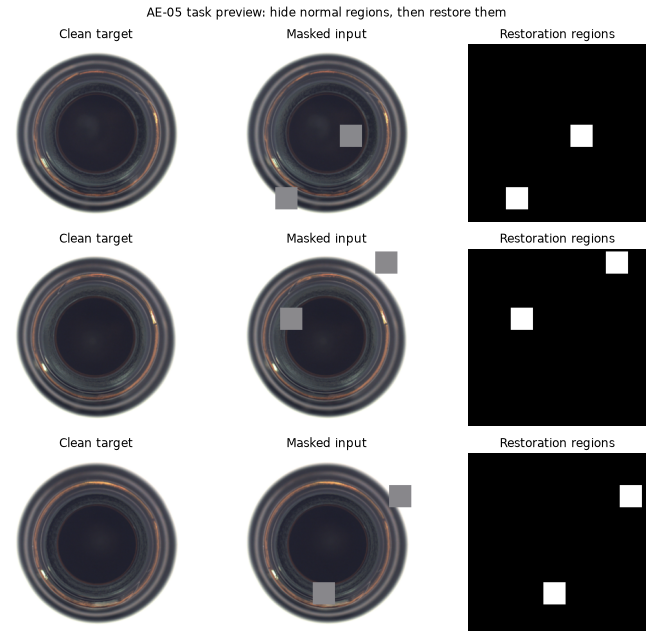

In [78]:
AE05_MAX_EPOCHS = 150
AE05_LEARNING_RATE = 1e-3
PATCH_SIZE = 32
PATCHES_PER_IMAGE = 2
MASKED_LOSS_WEIGHT = 0.75

def apply_mean_cutout(images, patch_size, patches_per_image, generator):
    """Replace random square regions with each image's mean colour and return a 1-channel mask."""
    corrupted_images = images.clone()
    mask = torch.zeros((len(images), 1, images.shape[-2], images.shape[-1]), device=images.device)
    height, width = images.shape[-2:]

    for image_index in range(len(images)):
        fill_value = images[image_index].mean(dim=(1, 2), keepdim=True)
        for _ in range(patches_per_image):
            top = int(torch.randint(height - patch_size + 1, (1,), generator=generator).item())
            left = int(torch.randint(width - patch_size + 1, (1,), generator=generator).item())
            corrupted_images[image_index, :, top:top + patch_size, left:left + patch_size] = fill_value
            mask[image_index, :, top:top + patch_size, left:left + patch_size] = 1.0

    return corrupted_images, mask

def restoration_losses(reconstruction, clean_images, mask):
    """Return weighted task loss, masked-region MSE, and whole-image clean-target MSE."""
    squared_error = (reconstruction - clean_images).pow(2)
    masked_mse = (squared_error * mask).sum() / (mask.sum() * clean_images.shape[1])
    full_mse = squared_error.mean()
    task_loss = MASKED_LOSS_WEIGHT * masked_mse + (1 - MASKED_LOSS_WEIGHT) * full_mse
    return task_loss, masked_mse, full_mse

# AE-05 has its own deterministic shuffle order because it is a fresh experiment.
ae05_loader_generator = torch.Generator().manual_seed(SEED + 5)
train_loader_ae05 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=ae05_loader_generator,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

preview_images, _, _ = next(iter(validation_loader))
preview_images = preview_images[:3].to(DEVICE, non_blocking=PIN_MEMORY)
preview_generator = torch.Generator().manual_seed(SEED + 500)
preview_corrupted, preview_mask = apply_mean_cutout(
    preview_images, PATCH_SIZE, PATCHES_PER_IMAGE, preview_generator
)

figure, axes = plt.subplots(3, 3, figsize=(10, 9))
for image_index in range(3):
    axes[image_index, 0].imshow(preview_images[image_index].permute(1, 2, 0).cpu())
    axes[image_index, 0].set_title('Clean target')
    axes[image_index, 1].imshow(preview_corrupted[image_index].permute(1, 2, 0).cpu())
    axes[image_index, 1].set_title('Masked input')
    axes[image_index, 2].imshow(preview_mask[image_index, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[image_index, 2].set_title('Restoration regions')
    for axis in axes[image_index]:
        axis.axis('off')
figure.suptitle('AE-05 task preview: hide normal regions, then restore them')
plt.tight_layout()
plt.show()


Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae05_masked_restoration.pt
AE-05 best epoch by masked validation loss: 141
AE-05 best masked validation MSE: 0.005139


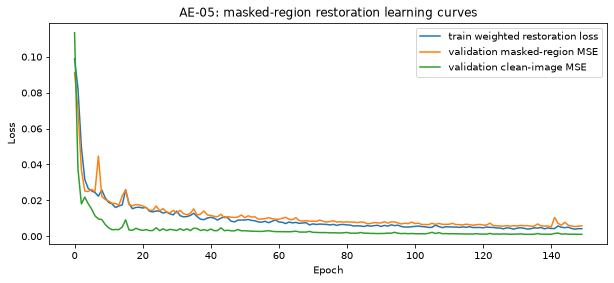

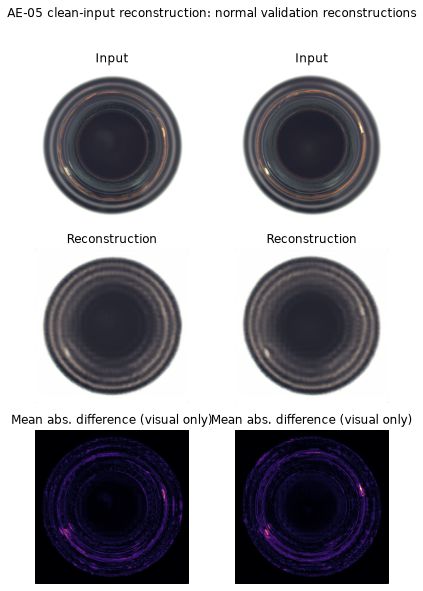

In [119]:
torch.manual_seed(SEED + 5)
RETRAIN_AE05 = False  # True deliberately retrains and replaces the checkpoint.
AE05_CHECKPOINT_PATH = MODELS_DIR / 'ae05_masked_restoration.pt'
AE05_CHECKPOINT_CONFIG = {
    'architecture': 'ConvAutoencoder',
    'seed': SEED + 5,
    'batch_size': BATCH_SIZE,
    'max_epochs': AE05_MAX_EPOCHS,
    'learning_rate': AE05_LEARNING_RATE,
    'patch_size': PATCH_SIZE,
    'patches_per_image': PATCHES_PER_IMAGE,
    'masked_loss_weight': MASKED_LOSS_WEIGHT,
}
model_ae05 = ConvAutoencoder().to(DEVICE)
optimizer_ae05 = torch.optim.Adam(model_ae05.parameters(), lr=AE05_LEARNING_RATE)
history_ae05 = {'train_task_loss': [], 'masked_validation_loss': [], 'clean_validation_mse': []}
best_masked_validation_loss_ae05 = float('inf')
best_epoch_ae05 = 0
best_state_ae05 = None
train_mask_generator = torch.Generator().manual_seed(SEED + 501)
train_ae05 = RETRAIN_AE05 or not AE05_CHECKPOINT_PATH.exists()
if not train_ae05:
    metadata_ae05 = load_model_checkpoint(
        AE05_CHECKPOINT_PATH, model_ae05, expected_experiment='AE-05'
    )
    if metadata_ae05.get('config') != AE05_CHECKPOINT_CONFIG:
        raise ValueError(
            'AE-05 checkpoint settings differ from this notebook. '
            'Set RETRAIN_AE05=True only if replacement is intended.'
        )
    history_ae05 = metadata_ae05['history']
    best_masked_validation_loss_ae05 = metadata_ae05[
        'best_masked_validation_loss'
    ]
    best_epoch_ae05 = metadata_ae05['best_epoch']
    best_state_ae05 = {
        key: value.detach().cpu().clone()
        for key, value in model_ae05.state_dict().items()
    }
else:
    print('Training AE-05 because retraining was requested or no checkpoint exists.')

for epoch in (range(1, AE05_MAX_EPOCHS + 1) if train_ae05 else []):
    model_ae05.train()
    train_loss_total, train_image_count = 0.0, 0
    for clean_images, _, _ in train_loader_ae05:
        clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY)
        masked_inputs, mask = apply_mean_cutout(
            clean_images, PATCH_SIZE, PATCHES_PER_IMAGE, train_mask_generator
        )
        optimizer_ae05.zero_grad()
        reconstruction = model_ae05(masked_inputs)
        task_loss, _, _ = restoration_losses(reconstruction, clean_images, mask)
        task_loss.backward()
        optimizer_ae05.step()
        train_loss_total += task_loss.item() * len(clean_images)
        train_image_count += len(clean_images)

    # Re-create this generator every epoch: every validation epoch sees the same masks.
    validation_mask_generator = torch.Generator().manual_seed(SEED + 502)
    model_ae05.eval()
    masked_loss_total = clean_mse_total = 0.0
    validation_image_count = 0
    with torch.inference_mode():
        for clean_images, _, _ in validation_loader:
            clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY)
            masked_inputs, mask = apply_mean_cutout(
                clean_images, PATCH_SIZE, PATCHES_PER_IMAGE, validation_mask_generator
            )
            masked_reconstruction = model_ae05(masked_inputs)
            _, masked_mse, _ = restoration_losses(masked_reconstruction, clean_images, mask)
            clean_reconstruction = model_ae05(clean_images)
            clean_mse = criterion(clean_reconstruction, clean_images)
            masked_loss_total += masked_mse.item() * len(clean_images)
            clean_mse_total += clean_mse.item() * len(clean_images)
            validation_image_count += len(clean_images)

    train_task_loss = train_loss_total / train_image_count
    masked_validation_loss = masked_loss_total / validation_image_count
    clean_validation_mse = clean_mse_total / validation_image_count
    history_ae05['train_task_loss'].append(train_task_loss)
    history_ae05['masked_validation_loss'].append(masked_validation_loss)
    history_ae05['clean_validation_mse'].append(clean_validation_mse)

    if masked_validation_loss < best_masked_validation_loss_ae05:
        best_masked_validation_loss_ae05 = masked_validation_loss
        best_epoch_ae05 = epoch
        best_state_ae05 = {key: value.detach().cpu().clone() for key, value in model_ae05.state_dict().items()}

    print(
        f'Epoch {epoch:03d}: train task={train_task_loss:.6f}, '
        f'masked validation={masked_validation_loss:.6f}, clean validation MSE={clean_validation_mse:.6f}'
    )

model_ae05.load_state_dict(best_state_ae05)
if train_ae05:
    save_model_checkpoint(
        AE05_CHECKPOINT_PATH, model_ae05,
        metadata={
            'experiment': 'AE-05',
            'config': AE05_CHECKPOINT_CONFIG,
            'best_epoch': best_epoch_ae05,
            'best_masked_validation_loss': best_masked_validation_loss_ae05,
            'history': history_ae05,
        },
    )
print(f'AE-05 best epoch by masked validation loss: {best_epoch_ae05}')
print(f'AE-05 best masked validation MSE: {best_masked_validation_loss_ae05:.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history_ae05['train_task_loss'], label='train weighted restoration loss')
plt.plot(history_ae05['masked_validation_loss'], label='validation masked-region MSE')
plt.plot(history_ae05['clean_validation_mse'], label='validation clean-image MSE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AE-05: masked-region restoration learning curves')
plt.legend()
plt.show()

show_reconstructions(model_ae05, validation_loader, experiment_name='AE-05 clean-input reconstruction', count=2)


### Did AE-05 actually restore the hidden regions?

This figure is the key visual check for AE-05. Read each row from left to right: the original clean validation image (our target), the masked input that the model receives, its reconstruction from that masked input, the remaining absolute reconstruction error, and the locations that were deliberately hidden. Bright areas in the error map mean the reconstruction differs more from the clean target.

The masking generator uses the same seed as validation, so these are the same reproducible masking conditions used when selecting the best AE-05 epoch.


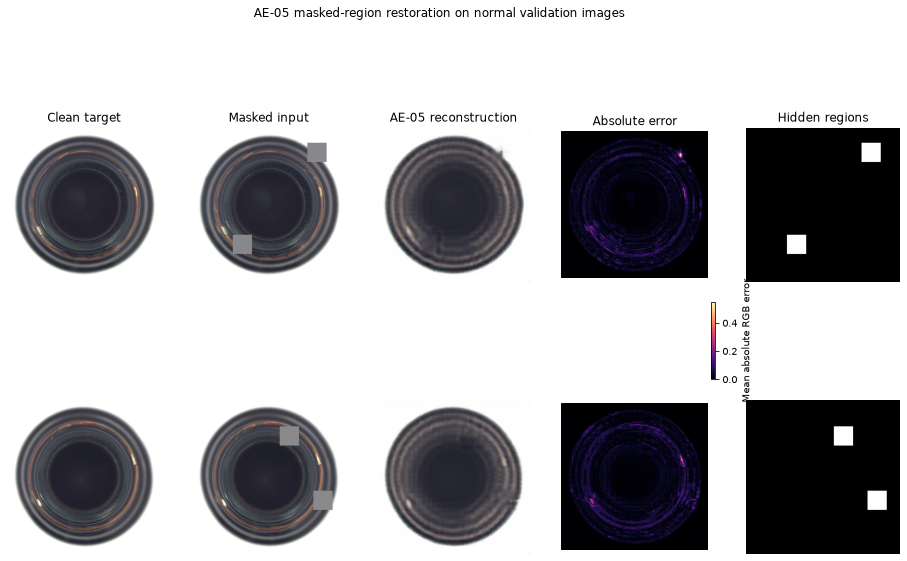

In [121]:
restoration_images, _, _ = next(iter(validation_loader))
restoration_images = restoration_images[:3].to(DEVICE, non_blocking=PIN_MEMORY)
restoration_generator = torch.Generator().manual_seed(SEED + 502)
restoration_inputs, restoration_mask = apply_mean_cutout(
    restoration_images, PATCH_SIZE, PATCHES_PER_IMAGE, restoration_generator
)

model_ae05.eval()
with torch.inference_mode():
    restoration_outputs = model_ae05(restoration_inputs)

error_maps = (restoration_outputs - restoration_images).abs().mean(dim=1)
error_max = error_maps.max().item()
figure, axes = plt.subplots(2, 5, figsize=(16, 9))
column_titles = ['Clean target', 'Masked input', 'AE-05 reconstruction', 'Absolute error', 'Hidden regions']
for image_index in range(2):
    axes[image_index, 0].imshow(restoration_images[image_index].permute(1, 2, 0).cpu())
    axes[image_index, 1].imshow(restoration_inputs[image_index].permute(1, 2, 0).cpu())
    axes[image_index, 2].imshow(restoration_outputs[image_index].permute(1, 2, 0).cpu())
    error_image = axes[image_index, 3].imshow(
        error_maps[image_index].cpu(), cmap='magma', vmin=0, vmax=error_max
    )
    axes[image_index, 4].imshow(restoration_mask[image_index, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    for column_index, axis in enumerate(axes[image_index]):
        if image_index == 0:
            axis.set_title(column_titles[column_index])
        axis.axis('off')

figure.colorbar(error_image, ax=axes[:, 3], fraction=0.025, pad=0.02, label='Mean absolute RGB error')
figure.suptitle('AE-05 masked-region restoration on normal validation images', y=1.01)
# plt.tight_layout()
plt.show()


## 5. Anomaly scores and thresholds

We use three scoring methods. It is important to separate how a model was trained from how we calculate its anomaly score:

- **AE-04 clean reconstruction:** give AE-04 a clean image and average the squared reconstruction error over the whole image.
- **AE-05 clean-input scoring:** give AE-05 a clean image and calculate the same whole-image error.
- **AE-05 masked-restoration scoring:** repeatedly hide different regions, measure error only in the hidden regions, and combine those errors into one anomaly map.

For masked scoring, we use the same patch size, number of patches, and average-colour fill. We create 32 masked versions so that every pixel is hidden and checked once. For pixel `p`, the combined error is:

$$
A(p) = \frac{\sum_j M_j(p)\left[\frac{1}{3}\sum_{c=1}^{3}(\hat{x}_{j,c}(p)-x_c(p))^2\right]}{\sum_j M_j(p)}.
$$

The final image score is the mean of the highest-error 1% of pixels. We chose 1% as a reasonable starting point: averaging the whole image may hide a small defect, while using only one pixel may be too sensitive to noise. We did not search for the best percentage.

Each scoring method gets its own threshold from the 95th percentile of its normal validation scores. With only 42 validation images, this threshold is approximate, so we also report how many validation images it flags.


AE-05 (masked-restoration scoring) masked versions per image: 32
AE-05 (masked-restoration scoring) anomaly-map aggregation: mean of top 1% pixels
AE-04 clean reconstruction:
  95th-percentile threshold: 0.000461
  Empirical validation false-positive rate: 7.1% (3 of 42)
AE-05 (clean-input scoring):
  95th-percentile threshold: 0.001298
  Empirical validation false-positive rate: 7.1% (3 of 42)
AE-05 (masked-restoration scoring):
  95th-percentile threshold: 0.203310
  Empirical validation false-positive rate: 7.1% (3 of 42)


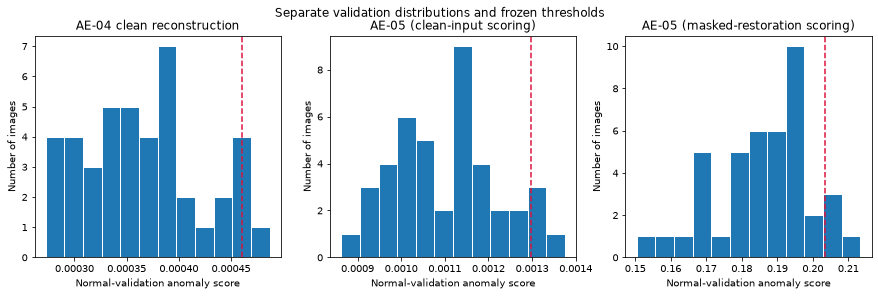

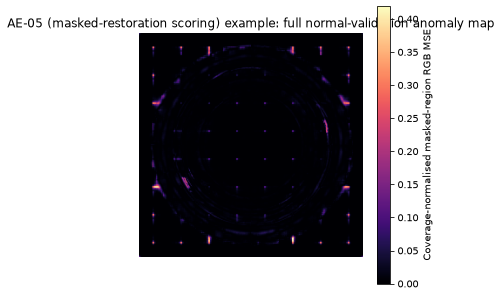

In [122]:
AE04_SCORE_NAME = 'AE-04 clean reconstruction'
AE05_CLEAN_SCORE_NAME = 'AE-05 (clean-input scoring)'
AE05_RESTORATION_SCORE_NAME = 'AE-05 (masked-restoration scoring)'
RESTORATION_TOP_FRACTION = 0.01

def paired_patch_schedule(height, width, patch_size):
    """Pair non-overlapping grid patches so every pixel is held out exactly once."""
    if height % patch_size or width % patch_size:
        raise ValueError('Image dimensions must be divisible by the restoration patch size.')
    positions = [
        (top, left)
        for top in range(0, height, patch_size)
        for left in range(0, width, patch_size)
    ]
    if len(positions) % PATCHES_PER_IMAGE:
        raise ValueError('The patch grid must divide evenly into masked versions.')
    if PATCHES_PER_IMAGE != 2:
        raise ValueError('AE-05 (masked-restoration scoring) is frozen to two simultaneously hidden patches.')
    half = len(positions) // 2
    return list(zip(positions[:half], positions[half:]))

def masked_restoration_scores(model_to_score, loader):
    """Return AE-05 (masked-restoration scoring) top-1% scores and coverage-normalised anomaly maps."""
    model_to_score.eval()
    scores, labels, paths, anomaly_maps = [], [], [], []

    with torch.inference_mode():
        for images, batch_labels, batch_paths in loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            height, width = images.shape[-2:]
            schedule = paired_patch_schedule(height, width, PATCH_SIZE)
            error_sum = torch.zeros((len(images), height, width), device=images.device)
            coverage = torch.zeros((height, width), device=images.device)
            fill_values = images.mean(dim=(2, 3), keepdim=True)

            for patch_pair in schedule:
                masked_inputs = images.clone()
                spatial_mask = torch.zeros((height, width), device=images.device)
                for top, left in patch_pair:
                    bottom, right = top + PATCH_SIZE, left + PATCH_SIZE
                    masked_inputs[:, :, top:bottom, left:right] = fill_values
                    spatial_mask[top:bottom, left:right] = 1.0

                expected_area = PATCHES_PER_IMAGE * PATCH_SIZE**2
                if int(spatial_mask.sum().item()) != expected_area:
                    raise RuntimeError('AE-05 (masked-restoration scoring) inference patches must not overlap.')
                reconstructions = model_to_score(masked_inputs)
                rgb_mse = (reconstructions - images).square().mean(dim=1)
                error_sum += rgb_mse * spatial_mask
                coverage += spatial_mask

            if not torch.all(coverage > 0):
                raise RuntimeError('Every scored pixel must be covered by an AE-05 (masked-restoration scoring) mask.')
            anomaly_map = error_sum / coverage.unsqueeze(0)
            top_pixel_count = max(
                1, int(np.ceil(anomaly_map[0].numel() * RESTORATION_TOP_FRACTION))
            )
            batch_scores = torch.topk(
                anomaly_map.flatten(start_dim=1), top_pixel_count, dim=1
            ).values.mean(dim=1)

            scores.extend(batch_scores.cpu().numpy())
            labels.extend(batch_labels.numpy())
            paths.extend(batch_paths)
            anomaly_maps.append(anomaly_map.cpu().numpy())

    return np.asarray(scores), np.asarray(labels), paths, np.concatenate(anomaly_maps)

validation_scores_ae04, _, _ = clean_reconstruction_scores(model_ae04, validation_loader)
validation_scores_ae05_clean, _, _ = clean_reconstruction_scores(model_ae05, validation_loader)
validation_scores_ae05_restoration, _, _, validation_maps_ae05_restoration = masked_restoration_scores(
    model_ae05, validation_loader
)
frozen_validation_scores = {
    AE04_SCORE_NAME: validation_scores_ae04,
    AE05_CLEAN_SCORE_NAME: validation_scores_ae05_clean,
    AE05_RESTORATION_SCORE_NAME: validation_scores_ae05_restoration,
}
validation_thresholds = {
    experiment_name: np.percentile(scores, THRESHOLD_PERCENTILE)
    for experiment_name, scores in frozen_validation_scores.items()
}

schedule = paired_patch_schedule(IMAGE_SIZE, IMAGE_SIZE, PATCH_SIZE)
print(f'AE-05 (masked-restoration scoring) masked versions per image: {len(schedule)}')
print(f'AE-05 (masked-restoration scoring) anomaly-map aggregation: mean of top {RESTORATION_TOP_FRACTION:.0%} pixels')
for experiment_name, scores in frozen_validation_scores.items():
    experiment_threshold = validation_thresholds[experiment_name]
    print(f'{experiment_name}:')
    print(f'  {THRESHOLD_PERCENTILE}th-percentile threshold: {experiment_threshold:.6f}')
    print(f'  Empirical validation false-positive rate: {(scores > experiment_threshold).mean():.1%} ({(scores > experiment_threshold).sum()} of {len(scores)})')

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (experiment_name, scores) in zip(axes, frozen_validation_scores.items()):
    axis.hist(scores, bins=12, edgecolor='white')
    axis.axvline(validation_thresholds[experiment_name], color='crimson', linestyle='--')
    axis.set_title(experiment_name)
    axis.set_xlabel('Normal-validation anomaly score')
    axis.set_ylabel('Number of images')
figure.suptitle('Separate validation distributions and frozen thresholds')
# plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(validation_maps_ae05_restoration[0], cmap='magma')
plt.colorbar(label='Coverage-normalised masked-region RGB MSE')
plt.title('AE-05 (masked-restoration scoring) example: full normal-validation anomaly map')
plt.axis('off')
plt.show()


### AE-01 to AE-04 validation comparison and separate AE-05 control

AE-01 to AE-04 continue the same clean-reconstruction model, so we compare their normal validation scores with box plots. AE-05 learned a different task, so its clean-input scores are shown separately. Both figures use whole-image MSE, but they only show reconstruction of normal validation images, not defect detection.


AE-01: mean=0.001073, median=0.001083, max=0.001338
AE-02: mean=0.000465, median=0.000463, max=0.000602
AE-03: mean=0.000374, median=0.000371, max=0.000497
AE-04: mean=0.000366, median=0.000363, max=0.000487
AE-05 (clean-input scoring): mean=0.001103, median=0.001105, max=0.001375


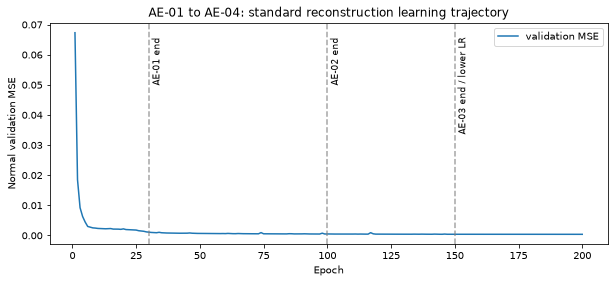

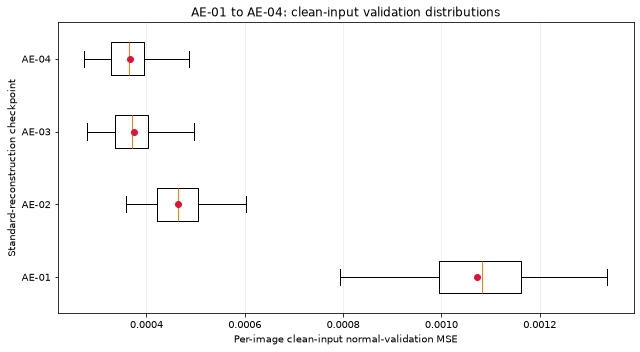

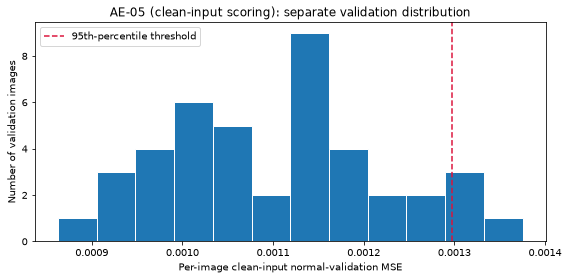

In [82]:
validation_scores_ae01, _, _ = clean_reconstruction_scores(model_ae01, validation_loader)
validation_scores_ae02, _, _ = clean_reconstruction_scores(model_ae02, validation_loader)
validation_scores_ae03, _, _ = clean_reconstruction_scores(model_ae03, validation_loader)
# Reuse the scores already calculated for the frozen protocols above.
standard_experiment_scores = {
    'AE-01': validation_scores_ae01,
    'AE-02': validation_scores_ae02,
    'AE-03': validation_scores_ae03,
    'AE-04': validation_scores_ae04,
}

for experiment_name, scores in standard_experiment_scores.items():
    print(
        f'{experiment_name}: mean={scores.mean():.6f}, '
        f'median={np.median(scores):.6f}, max={scores.max():.6f}'
    )

print(
    f'AE-05 (clean-input scoring): mean={validation_scores_ae05_clean.mean():.6f}, '
    f'median={np.median(validation_scores_ae05_clean):.6f}, '
    f'max={validation_scores_ae05_clean.max():.6f}'
)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(history_ae04['validation_loss']) + 1), history_ae04['validation_loss'], label='validation MSE')
for boundary, label in [(30, 'AE-01 end'), (100, 'AE-02 end'), (150, 'AE-03 end / lower LR')]:
    plt.axvline(boundary, color='grey', linestyle='--', alpha=0.7)
    plt.text(boundary + 1, plt.ylim()[1] * 0.93, label, rotation=90, va='top', fontsize=9)
plt.xlabel('Epoch')
plt.ylabel('Normal validation MSE')
plt.title('AE-01 to AE-04: standard reconstruction learning trajectory')
plt.legend()
plt.show()

figure, axis = plt.subplots(figsize=(9, 5))
axis.boxplot(
    list(standard_experiment_scores.values()),
    tick_labels=list(standard_experiment_scores.keys()),
    orientation='horizontal',
    showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': 'crimson', 'markeredgecolor': 'crimson'},
)
axis.set_xlabel('Per-image clean-input normal-validation MSE')
axis.set_ylabel('Standard-reconstruction checkpoint')
axis.set_title('AE-01 to AE-04: clean-input validation distributions')
axis.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

ae05_clean_threshold = validation_thresholds[AE05_CLEAN_SCORE_NAME]
plt.figure(figsize=(8, 4))
plt.hist(validation_scores_ae05_clean, bins=12, edgecolor='white')
plt.axvline(
    ae05_clean_threshold, color='crimson', linestyle='--',
    label=f'{THRESHOLD_PERCENTILE}th-percentile threshold'
)
plt.xlabel('Per-image clean-input normal-validation MSE')
plt.ylabel('Number of validation images')
plt.title('AE-05 (clean-input scoring): separate validation distribution')
plt.legend()
plt.tight_layout()
plt.show()


## 6. What we tried before the first Bottle evaluation

This table keeps the path of the project visible, including an earlier restart that was not directly comparable. AE-06 to AE-08 appear later because we designed them after learning from the first Bottle results.

| ID | What we wanted to learn | What changed | Validation result | Next step | Why |
| --- | --- | --- | --- | --- | --- |
| AE-01 | A three-stage convolutional autoencoder learns normal Bottle structure. | New reconstruction baseline; RGB 256 x 256; MSE; 30 epochs. | Train and validation MSE fell together to 0.001108 and 0.001073 at epoch 30. | Continue | Validation loss was still improving at the 30-epoch budget, with no sustained train/validation gap. |
| AE-02 (earlier restart) | See how a new 60-epoch run behaves. | New model weights, new data order, and 60 epochs. | Best validation MSE: 0.000627 at epoch 60, using the earlier averaging calculation. | Keep as part of our learning record, but do not compare it directly with AE-01. | Several details changed at once. |
| AE-02 (main continuation) | See whether AE-01 improves with more training. | Continue the same model from epoch 31 to 100. | Best validation MSE: 0.000465 at epoch 97, 56.7% lower than AE-01; threshold: 0.000578. | Continue to AE-03. | The best result came near the end of the run. |
| AE-03 | See whether another 50 epochs help. | Continue AE-02 from epoch 100 to 150. | Best validation MSE: 0.000374 at epoch 150, 19.6% lower than AE-02. | Continue to AE-04. | It was still improving, but more slowly. |
| AE-04 | See whether smaller learning-rate updates improve the model. | Continue AE-03 to epoch 200 and change Adam from 1e-3 to 1e-4. | Best validation MSE: 0.000366, only 2.1% below AE-03; threshold: 0.000461. | Stop extending this model. | The extra improvement was small. |
| AE-05 (masked-region training) | Learn normal Bottle structure by restoring hidden regions instead of copying every input pixel. | New model; two 32 x 32 average-colour patches; 75% hidden-region plus 25% whole-image MSE; up to 150 epochs. | Best masked validation MSE: 0.005139 at epoch 141. Clean-input mean: 0.001103; threshold: 0.001298. | Keep the selected model and try both scoring methods. | It learned restoration, although its clean-image reconstruction error was about three times AE-04's. |
| AE-05 (masked scoring) | Check whether unusual regions are harder to restore. | Same AE-05 model; 32 masked versions covering every pixel once; top-1% mean error. | Threshold and false-alarm count calculated from 42 normal validation images. | Use this as AE-05's second scoring method. | It matches the task used during training. |

**Summary before testing.** More training greatly improved AE-01 through AE-03, but AE-04 gained only another 2.1%, so we stopped extending the original architecture. AE-05 successfully learned to restore hidden regions, although it reconstructed clean validation images less accurately than AE-04. This did not yet tell us which model would detect defects better. We therefore kept both models and evaluated AE-05 with both clean and masked scoring.


## 7. Notes before testing

AE-01 to AE-04 show steadily lower reconstruction error on normal validation images. The largest improvement came from AE-01 to AE-02; by AE-04, the extra improvement was only 2.1%. We therefore stop extending this version.

The saved figures show that AE-04 preserves the main circular Bottle structure but smooths fine texture and reflections. Whole-image MSE may therefore miss small defects or react to harmless lighting changes. AE-05 restores the broad structure of hidden regions, but its outputs are even smoother. Its clean-input validation MSE is about three times AE-04's.

We keep AE-04 as the clean-reconstruction model. We evaluate the same AE-05 model with two scoring methods: clean-input scoring and masked-restoration scoring. Each method uses its own threshold calculated from normal validation images.


## 8. Possible future work on another product

We kept this notebook focused on Bottle so every autoencoder could be compared with the same baseline. Future work could try `capsule`, `pill`, `cable`, or `screw`, which contain different kinds of defects and variation.

A new category should use its own training, validation, and test data and should be recorded separately rather than replacing the Bottle results.


In [83]:
# Runnable harder-product work will live in a separate notebook.


## 9. Models and scores used for the first test evaluation

Before running this evaluation, we had completed AE-04 and AE-05 and calculated their thresholds from normal validation images. AE-04 is the clean-reconstruction model. The two AE-05 rows below are two scoring methods applied to the **same trained AE-05 model**, not two separate models.

| Method | Trained model | Input used for scoring | Anomaly score | Threshold source | Purpose |
| --- | --- | --- | --- | --- | --- |
| AE-04 | `model_ae04` | Clean image | Whole-image RGB MSE | AE-04 normal-validation 95th percentile | Primary clean-reconstruction method |
| AE-05 (clean-input scoring) | `model_ae05` | Clean image | Whole-image RGB MSE | AE-05 (clean-input scoring) normal-validation 95th percentile | Diagnostic/control |
| AE-05 (masked-restoration scoring) | `model_ae05` | 32 deterministic masked versions, each with two non-overlapping 32 x 32 mean-filled patches | Mean of the highest 1% of the coverage-normalised masked-region RGB-MSE map | AE-05 (masked-restoration scoring) normal-validation 95th percentile | Masked-restoration method |

The AE-05 masked method covers every pixel once and averages the highest-error 1% of pixels. This percentage was a starting choice, not a searched optimum. Because the validation set has only 42 images, its thresholds are approximate.

The next cell calculates AUROC, PR-AUC, balanced accuracy, and classification reports, then compares the autoencoders with the frozen ResNet-18 + 5-NN baseline.



AE-04 clean reconstruction
Frozen validation threshold: 0.000461
Image AUROC: 0.6167
PR-AUC: 0.8599
Balanced accuracy: 0.6405
              precision    recall  f1-score   support

        good       0.32      0.90      0.47        20
     anomaly       0.92      0.38      0.54        63

    accuracy                           0.51        83
   macro avg       0.62      0.64      0.50        83
weighted avg       0.78      0.51      0.52        83



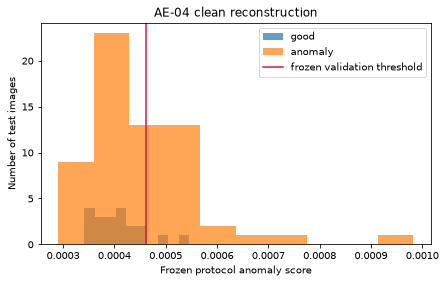


AE-05 (clean-input scoring)
Frozen validation threshold: 0.001298
Image AUROC: 0.7627
PR-AUC: 0.9239
Balanced accuracy: 0.7663
              precision    recall  f1-score   support

        good       0.46      0.85      0.60        20
     anomaly       0.93      0.68      0.79        63

    accuracy                           0.72        83
   macro avg       0.70      0.77      0.69        83
weighted avg       0.82      0.72      0.74        83



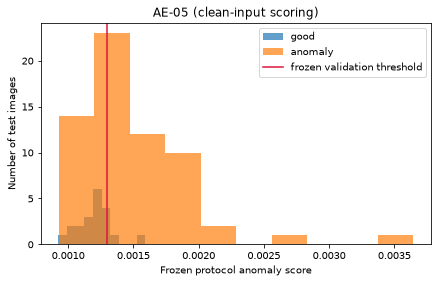


AE-05 (masked-restoration scoring)
Frozen validation threshold: 0.203310
Image AUROC: 0.6841
PR-AUC: 0.8996
Balanced accuracy: 0.7131
              precision    recall  f1-score   support

        good       0.37      0.95      0.53        20
     anomaly       0.97      0.48      0.64        63

    accuracy                           0.59        83
   macro avg       0.67      0.71      0.58        83
weighted avg       0.82      0.59      0.61        83



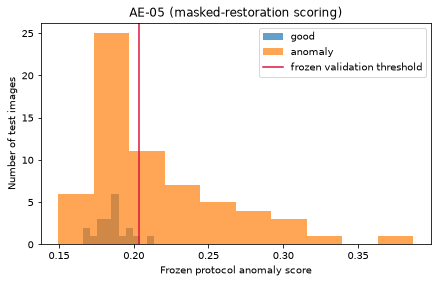

In [84]:
RUN_TEST_EVALUATION = True

if RUN_TEST_EVALUATION:
    frozen_test_methods = {
        AE04_SCORE_NAME: (model_ae04, clean_reconstruction_scores),
        AE05_CLEAN_SCORE_NAME: (model_ae05, clean_reconstruction_scores),
        AE05_RESTORATION_SCORE_NAME: (model_ae05, masked_restoration_scores),
    }
    if set(frozen_test_methods) != set(validation_thresholds):
        raise RuntimeError('Every frozen test protocol must have its own validation threshold.')

    test_dataset = MVTecImageDataset(bottle_test, transform=image_transform)
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    for protocol_name, (model_to_test, scoring_function) in frozen_test_methods.items():
        protocol_threshold = validation_thresholds[protocol_name]
        scoring_output = scoring_function(model_to_test, test_loader)
        test_scores, test_labels, _ = scoring_output[:3]
        test_predictions = (test_scores > protocol_threshold).astype(int)

        print(f'\n{protocol_name}')
        print(f'Frozen validation threshold: {protocol_threshold:.6f}')
        print(f'Image AUROC: {roc_auc_score(test_labels, test_scores):.4f}')
        print(f'PR-AUC: {average_precision_score(test_labels, test_scores):.4f}')
        print(f'Balanced accuracy: {balanced_accuracy_score(test_labels, test_predictions):.4f}')
        print(classification_report(
            test_labels, test_predictions, target_names=['good', 'anomaly'], zero_division=0
        ))

        plt.figure(figsize=(7, 4))
        plt.hist(test_scores[test_labels == 0], alpha=.7, label='good')
        plt.hist(test_scores[test_labels == 1], alpha=.7, label='anomaly')
        plt.axvline(protocol_threshold, color='crimson', label='frozen validation threshold')
        plt.xlabel('Frozen protocol anomaly score')
        plt.ylabel('Number of test images')
        plt.title(protocol_name)
        plt.legend()
        plt.show()
else:
    print('Autoencoder test evaluation remains disabled. Set RUN_TEST_EVALUATION=True only for the frozen one-time run.')


## 10. First Bottle test results

We evaluated the three autoencoder scoring methods on 83 Bottle test images: 20 good and 63 defective. Their models and validation-based thresholds had already been chosen.

| Method | Image AUROC | PR-AUC | Balanced accuracy | Good: correct / false alarms | Defects: detected / missed |
| --- | ---: | ---: | ---: | ---: | ---: |
| AE-04 clean reconstruction | 0.6167 | 0.8599 | 0.6405 | 18 / 2 | 24 / 39 |
| AE-05 (clean-input scoring) | **0.7627** | **0.9239** | **0.7663** | 17 / 3 | 43 / 20 |
| AE-05 (masked-restoration scoring) | 0.6841 | 0.8996 | 0.7131 | **19 / 1** | 30 / 33 |
| Frozen ResNet-18 + 5-NN baseline | **0.9881** | **0.9960** | **0.9433** | **19 / 1** | **59 / 4** |

AE-05 with clean-input scoring was the strongest autoencoder at this stage: it detected 43 of 63 defects while correctly accepting 17 of 20 good images. Masked-restoration scoring produced only one false alarm, but it missed 33 defects and did not improve AUROC or balanced accuracy. The masked scoring method therefore did not provide the expected overall improvement.

AE-04 achieved the lowest normal-validation reconstruction MSE, yet it was the weakest anomaly detector and missed 39 of 63 anomalies. This is important negative evidence: increasingly accurate reconstruction of normal images did not imply better defect separation. The high-capacity, lightly compressed autoencoder may also reconstruct anomalous structure, while whole-image MSE can dilute small local defects.

The masked-restoration experiment is still useful. AE-05 with clean-input scoring outperformed AE-04, so the artificial task appears to have changed what the model learned. However, AE-05 also started from different random weights, so this single run cannot show that masking alone caused the improvement.

The frozen ResNet-18 feature extractor is clearly stronger than every autoencoder. We report several metrics because the test set contains many more defective images than good images.

**Decision:** keep all results, including the weaker methods. We used these results to understand the autoencoders and to design the later AE-06 to AE-08 learning experiments. This means those later Bottle scores are useful course-project comparisons, but they are not results from a completely unseen final test set.


## 11. Looking at the errors

The following analysis helps us understand which defect types and sizes were difficult, what missed defects looked like, and which good images caused false alarms. These observations helped us form ideas for AE-06 to AE-08.


In [85]:
import pandas as pd
from IPython.display import display
from PIL import Image

# Recalculate the frozen scores so every protocol's per-image results are retained.
# This does not change any model, score, or threshold.
posthoc_frames = []
posthoc_anomaly_maps = {}
protocol_order = list(frozen_test_methods)

for protocol_name, (model_to_score, scoring_function) in frozen_test_methods.items():
    scoring_output = scoring_function(model_to_score, test_loader)
    protocol_scores, protocol_labels, protocol_paths = scoring_output[:3]
    protocol_threshold = validation_thresholds[protocol_name]
    protocol_frame = pd.DataFrame({
        'protocol': protocol_name,
        'path': [str(path) for path in protocol_paths],
        'label': protocol_labels.astype(int),
        'score': protocol_scores,
    })
    protocol_frame['threshold'] = protocol_threshold
    protocol_frame['score_over_threshold'] = protocol_frame['score'] / protocol_threshold
    protocol_frame['predicted_anomaly'] = protocol_frame['score'] > protocol_threshold
    posthoc_frames.append(protocol_frame)
    if len(scoring_output) > 3:
        posthoc_anomaly_maps[protocol_name] = dict(zip(protocol_frame['path'], scoring_output[3]))

test_metadata = bottle_test[['path', 'defect_type', 'mask_path', 'is_anomaly']].copy()
test_metadata['path'] = test_metadata['path'].astype(str)

def defect_area_percent(mask_path):
    if pd.isna(mask_path):
        return np.nan
    with Image.open(mask_path) as mask_image:
        binary_mask = np.asarray(mask_image) > 0
    return 100.0 * binary_mask.mean()

test_metadata['defect_area_percent'] = test_metadata['mask_path'].apply(defect_area_percent)
posthoc_test_results = pd.concat(posthoc_frames, ignore_index=True).merge(
    test_metadata, on='path', how='left', validate='many_to_one'
)
assert posthoc_test_results['defect_type'].notna().all()
assert (posthoc_test_results['label'].astype(bool) == posthoc_test_results['is_anomaly']).all()
print(f'Retained {len(posthoc_test_results)} protocol-image results for descriptive analysis.')


Retained 249 protocol-image results for descriptive analysis.


,protocol,defect_type,image_count,detected,median_score_over_threshold,missed,detection_rate
0,AE-04 clean reconstruction,broken_large,20,4,0.886377,16,0.200000
1,AE-04 clean reconstruction,broken_small,22,10,0.960259,12,0.454545
2,AE-04 clean reconstruction,contamination,21,10,0.968259,11,0.476190
5,AE-05 (clean-input scoring),contamination,21,12,1.046122,9,0.571429
4,AE-05 (clean-input scoring),broken_small,22,15,1.117024,7,0.681818
3,AE-05 (clean-input scoring),broken_large,20,16,1.092027,4,0.800000
8,AE-05 (masked-restoration scoring),contamination,21,5,0.890037,16,0.238095
6,AE-05 (masked-restoration scoring),broken_large,20,11,1.031618,9,0.550000
7,AE-05 (masked-restoration scoring),broken_small,22,14,1.064447,8,0.636364


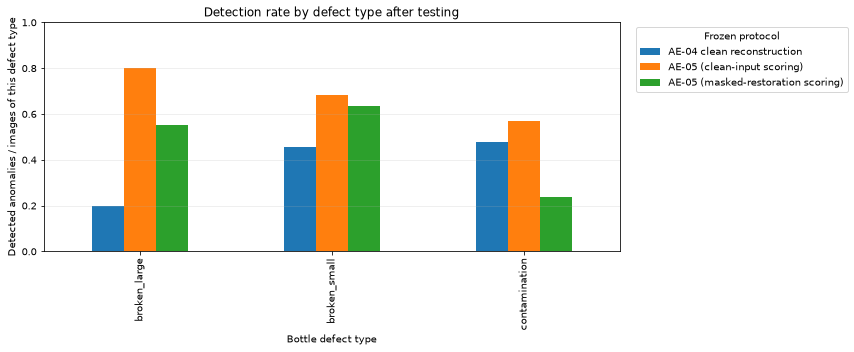

,good_images,false_alarms,false_alarm_rate
protocol,,,
AE-04 clean reconstruction,20,2,0.10
AE-05 (clean-input scoring),20,3,0.15
AE-05 (masked-restoration scoring),20,1,0.05


In [86]:
# 11.1 Detection rate by defect type and false alarms on good images
anomaly_results = posthoc_test_results[posthoc_test_results['label'].eq(1)].copy()
defect_type_summary = (
    anomaly_results.groupby(['protocol', 'defect_type'], observed=True)
    .agg(
        image_count=('path', 'size'),
        detected=('predicted_anomaly', 'sum'),
        median_score_over_threshold=('score_over_threshold', 'median'),
    )
    .reset_index()
)
defect_type_summary['missed'] = defect_type_summary['image_count'] - defect_type_summary['detected']
defect_type_summary['detection_rate'] = defect_type_summary['detected'] / defect_type_summary['image_count']
display(defect_type_summary.sort_values(['protocol', 'detection_rate', 'defect_type']))

detection_rate_by_type = defect_type_summary.pivot(
    index='defect_type', columns='protocol', values='detection_rate'
).reindex(columns=protocol_order)
axis = detection_rate_by_type.plot(kind='bar', figsize=(12, 5), ylim=(0, 1))
axis.set_ylabel('Detected anomalies / images of this defect type')
axis.set_xlabel('Bottle defect type')
axis.set_title('Detection rate by defect type after testing')
axis.legend(title='Frozen protocol', bbox_to_anchor=(1.02, 1), loc='upper left')
axis.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

false_alarm_summary = (
    posthoc_test_results[posthoc_test_results['label'].eq(0)]
    .groupby('protocol', observed=True)
    .agg(good_images=('path', 'size'), false_alarms=('predicted_anomaly', 'sum'))
    .reindex(protocol_order)
)
false_alarm_summary['false_alarm_rate'] = (
    false_alarm_summary['false_alarms'] / false_alarm_summary['good_images']
)
display(false_alarm_summary)


Defect-area ranges (% of original image):


,count,min,median,max
defect_size_group,,,,
small,21,0.575679,2.046667,3.236914
medium,21,3.334938,5.717778,9.461852
large,21,10.887901,14.680617,27.418642


,protocol,defect_size_group,image_count,detected,missed,detection_rate
0,AE-04 clean reconstruction,small,21,6,15,0.285714
1,AE-04 clean reconstruction,medium,21,12,9,0.571429
2,AE-04 clean reconstruction,large,21,6,15,0.285714
3,AE-05 (clean-input scoring),small,21,12,9,0.571429
4,AE-05 (clean-input scoring),medium,21,16,5,0.761905
5,AE-05 (clean-input scoring),large,21,15,6,0.714286
6,AE-05 (masked-restoration scoring),small,21,10,11,0.476190
7,AE-05 (masked-restoration scoring),medium,21,14,7,0.666667
8,AE-05 (masked-restoration scoring),large,21,6,15,0.285714


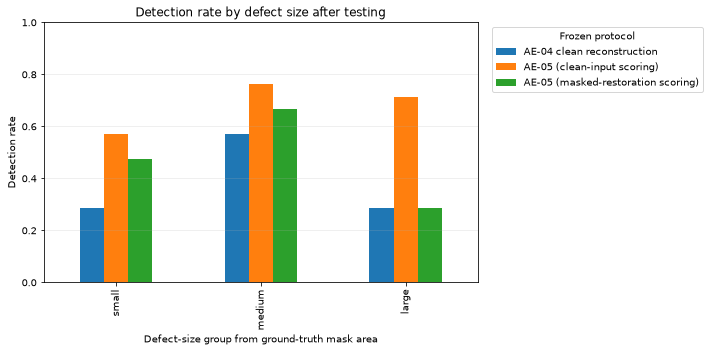

In [87]:
# 11.2 Detection rate by true defect-mask area
unique_anomaly_areas = (
    anomaly_results[['path', 'defect_area_percent']]
    .drop_duplicates('path')
    .sort_values('defect_area_percent')
)
assert unique_anomaly_areas['defect_area_percent'].notna().all()
unique_anomaly_areas['defect_size_group'] = pd.qcut(
    unique_anomaly_areas['defect_area_percent'].rank(method='first'),
    q=3, labels=['small', 'medium', 'large']
)
size_group_by_path = unique_anomaly_areas.set_index('path')['defect_size_group']
anomaly_results['defect_size_group'] = anomaly_results['path'].map(size_group_by_path)

size_boundaries = (
    unique_anomaly_areas.groupby('defect_size_group', observed=True)['defect_area_percent']
    .agg(['count', 'min', 'median', 'max'])
)
print('Defect-area ranges (% of original image):')
display(size_boundaries)

size_summary = (
    anomaly_results.groupby(['protocol', 'defect_size_group'], observed=True)
    .agg(image_count=('path', 'size'), detected=('predicted_anomaly', 'sum'))
    .reset_index()
)
size_summary['missed'] = size_summary['image_count'] - size_summary['detected']
size_summary['detection_rate'] = size_summary['detected'] / size_summary['image_count']
display(size_summary)

detection_rate_by_size = size_summary.pivot(
    index='defect_size_group', columns='protocol', values='detection_rate'
).reindex(index=['small', 'medium', 'large'], columns=protocol_order)
axis = detection_rate_by_size.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
axis.set_ylabel('Detection rate')
axis.set_xlabel('Defect-size group from ground-truth mask area')
axis.set_title('Detection rate by defect size after testing')
axis.legend(title='Frozen protocol', bbox_to_anchor=(1.02, 1), loc='upper left')
axis.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


In [123]:
protocol_order

['AE-04 clean reconstruction',
 'AE-05 (clean-input scoring)',
 'AE-05 (masked-restoration scoring)']

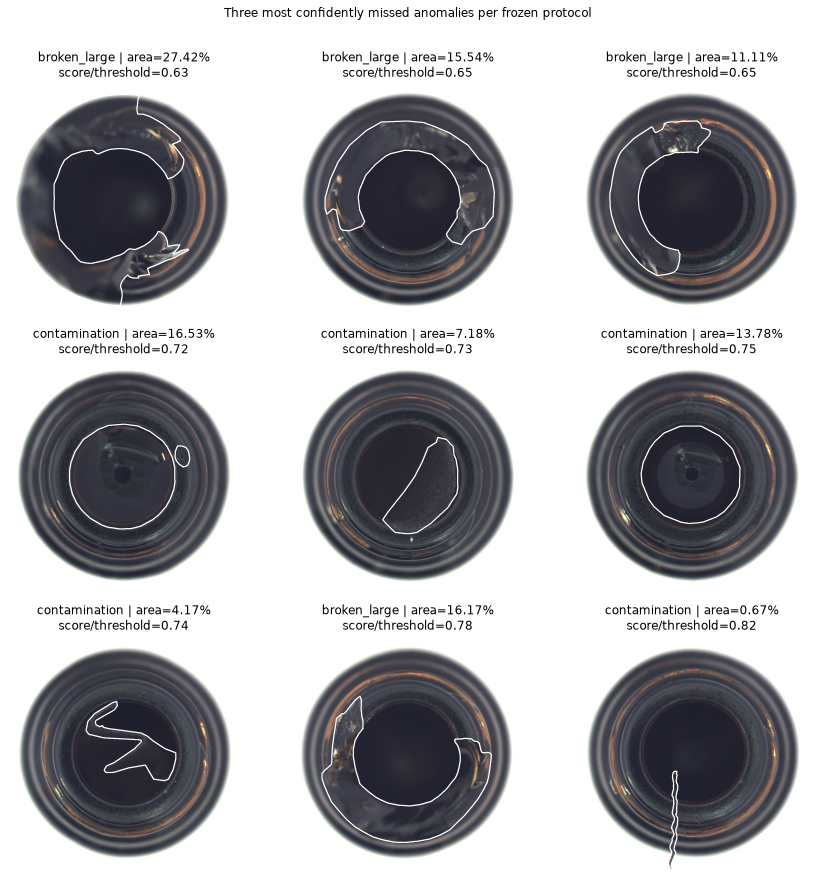

,protocol,filename,score,threshold,score_over_threshold
77,AE-04 clean reconstruction,014.png,0.000546,0.000461,1.185013
65,AE-04 clean reconstruction,002.png,0.000490,0.000461,1.064040
160,AE-05 (clean-input scoring),014.png,0.001591,0.001298,1.225855
148,AE-05 (clean-input scoring),002.png,0.001386,0.001298,1.067804
154,AE-05 (clean-input scoring),008.png,0.001310,0.001298,1.009865
239,AE-05 (masked-restoration scoring),010.png,0.213539,0.203310,1.050311


In [88]:
# 11.3 Most confidently missed anomalies and false-alarm identities
examples_per_protocol = 3
figure, axes = plt.subplots(
    len(protocol_order), examples_per_protocol,
    figsize=(4 * examples_per_protocol, 4 * len(protocol_order)), squeeze=False
)

for row_index, protocol_name in enumerate(protocol_order):
    missed_examples = (
        anomaly_results[
            anomaly_results['protocol'].eq(protocol_name)
            & ~anomaly_results['predicted_anomaly']
        ]
        .sort_values('score_over_threshold')
        .head(examples_per_protocol)
    )
    for column_index, axis in enumerate(axes[row_index]):
        if column_index >= len(missed_examples):
            axis.axis('off')
            continue
        example = missed_examples.iloc[column_index]
        with Image.open(example['path']) as image:
            axis.imshow(image.convert('RGB'))
        with Image.open(example['mask_path']) as mask_image:
            mask = np.asarray(mask_image) > 0
        axis.contour(mask, levels=[0.5], colors='white', linewidths=1.2)
        axis.set_title(
            f"{example['defect_type']} | area={example['defect_area_percent']:.2f}%\n"
            f"score/threshold={example['score_over_threshold']:.2f}"
        )
        axis.axis('off')
    axes[row_index, 0].set_ylabel(protocol_name, fontsize=9)

figure.suptitle('Three most confidently missed anomalies per frozen protocol', y=1.01)
plt.tight_layout()
plt.show()

false_alarm_examples = posthoc_test_results[
    posthoc_test_results['label'].eq(0) & posthoc_test_results['predicted_anomaly']
].copy()
false_alarm_examples['filename'] = false_alarm_examples['path'].map(lambda path: Path(path).name)
display(
    false_alarm_examples[
        ['protocol', 'filename', 'score', 'threshold', 'score_over_threshold']
    ].sort_values(['protocol', 'score_over_threshold'], ascending=[True, False])
)


### 11.4 What we learned from the test errors

AE-05 clean-input scoring was the most consistent autoencoder across all three defect types. It detected 80.0% of `broken_large`, 68.2% of `broken_small`, and 57.1% of `contamination` images. AE-04 detected only 20.0% of `broken_large` images and less than half of the other two types. AE-05 masked-restoration scoring detected 63.6% of `broken_small`, but only 55.0% of `broken_large` and 23.8% of `contamination` images. Masked scoring was therefore especially weak for contamination.

Defect size alone did not explain the errors. AE-05 clean-input scoring improved from 57.1% detection in the smallest third to 76.2% in the medium third and 71.4% in the largest third. In contrast, AE-04 detected only 28.6% of both the smallest and largest groups, while masked-restoration scoring fell to 28.6% for the largest group. The most confidently missed AE-04 examples were all `broken_large` defects covering 11.1% to 27.4% of the image. This shows that whole-image dilution of tiny defects is only part of the problem: the reconstruction model can also assign normal-looking scores to visually large structural damage.

The false alarms were few but partly repeatable. Good images `002.png` and `014.png` exceeded both clean-reconstruction thresholds; AE-05 clean-input scoring also flagged `008.png`. Masked-restoration scoring produced only one false alarm, `010.png`. The repeated clean-input false alarms suggest that some legitimate Bottle appearance variation is difficult for both reconstruction checkpoints, whereas the masked score is more conservative but misses many real defects.

### How we use these observations

These tables and figures show where each method succeeded or failed. They can suggest new experiments, but any later Bottle result must be described honestly as a follow-up on data we have already examined.


## 12. AE-06: stronger compression

AE-04 reconstructed normal validation images accurately but assigned normal-looking scores even to several visually large Bottle defects. We now test one directly motivated architectural change: add a fourth stride-2 encoder stage so the latent spatial size decreases from `32 x 32` to `16 x 16`. We keep 128 latent channels, giving `128 x 16 x 16 = 32,768` latent values instead of AE-04's `128 x 32 x 32 = 131,072`. Relative to the 196,608-value RGB input, value-count compression therefore increases from 1.5x to 6x.

We designed AE-06 after looking at the earlier Bottle errors. It starts from new random weights and still trains only on normal images. It keeps the same image size, data split, batch size, MSE loss, Adam optimiser, clean-input score, and validation-based threshold. It trains for 200 epochs, using `1e-3` through epoch 150 and `1e-4` afterward. Adding a stage changes both compression and model depth, so this one experiment cannot prove which detail caused any improvement.

**Question.** Does the more restrictive `16 x 16` latent representation make anomalous Bottle structure harder to reproduce and improve detection relative to AE-04?


In [89]:
class ConvAutoencoder16(nn.Module):
    """Four-stage autoencoder with a 128 x 16 x 16 latent tensor."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, images):
        return self.decoder(self.encoder(images))

torch.manual_seed(SEED + 6)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 6)
model_ae06 = ConvAutoencoder16().to(DEVICE)

sample_images_ae06, _, _ = next(iter(validation_loader))
with torch.inference_mode():
    sample_latent_ae06 = model_ae06.encoder(sample_images_ae06[:1].to(DEVICE))
    sample_reconstruction_ae06 = model_ae06(sample_images_ae06[:1].to(DEVICE))

assert tuple(sample_latent_ae06.shape[1:]) == (128, 16, 16)
assert sample_reconstruction_ae06.shape == sample_images_ae06[:1].shape
ae06_parameter_count = sum(parameter.numel() for parameter in model_ae06.parameters())
ae06_input_values = sample_images_ae06[0].numel()
ae06_latent_values = sample_latent_ae06[0].numel()
print(model_ae06)
print(f'Trainable parameters: {ae06_parameter_count:,}')
print(f'Input shape:  {tuple(sample_images_ae06[:1].shape)} ({ae06_input_values:,} values)')
print(f'Latent shape: {tuple(sample_latent_ae06.shape)} ({ae06_latent_values:,} values)')
print(f'Value-count compression: {ae06_input_values / ae06_latent_values:.2f}x')


ConvAutoencoder16(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)
Trainable parameters: 855,619
Input shape:  (1, 3, 256, 256) (196,608 values)
Latent shape: (1, 128, 16, 16) (32,768 values)
Value-count compression: 

Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae06_conv_autoencoder16.pt
AE-06 best epoch: 199
AE-06 best validation MSE: 0.000553


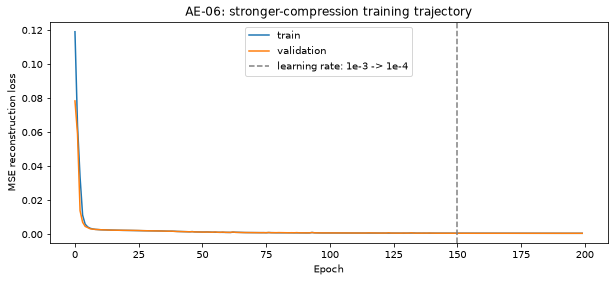

Input shape:  (1, 3, 256, 256) (196,608 values)
Latent shape: (1, 128, 16, 16) (32,768 values)
Value-count compression: 6.00x


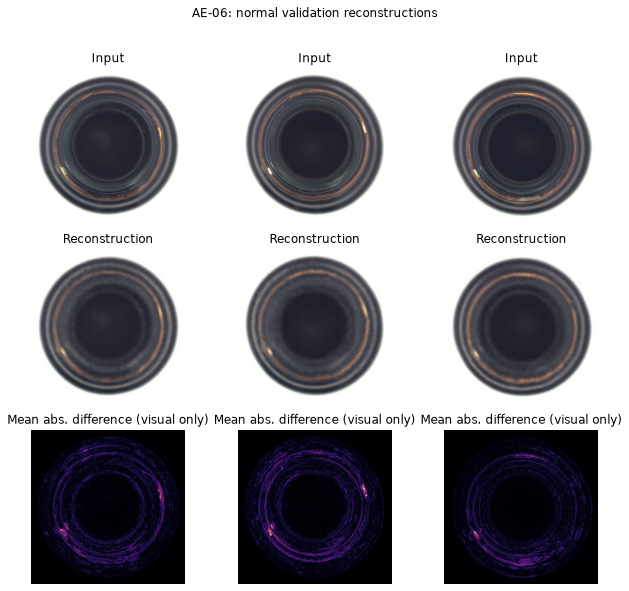

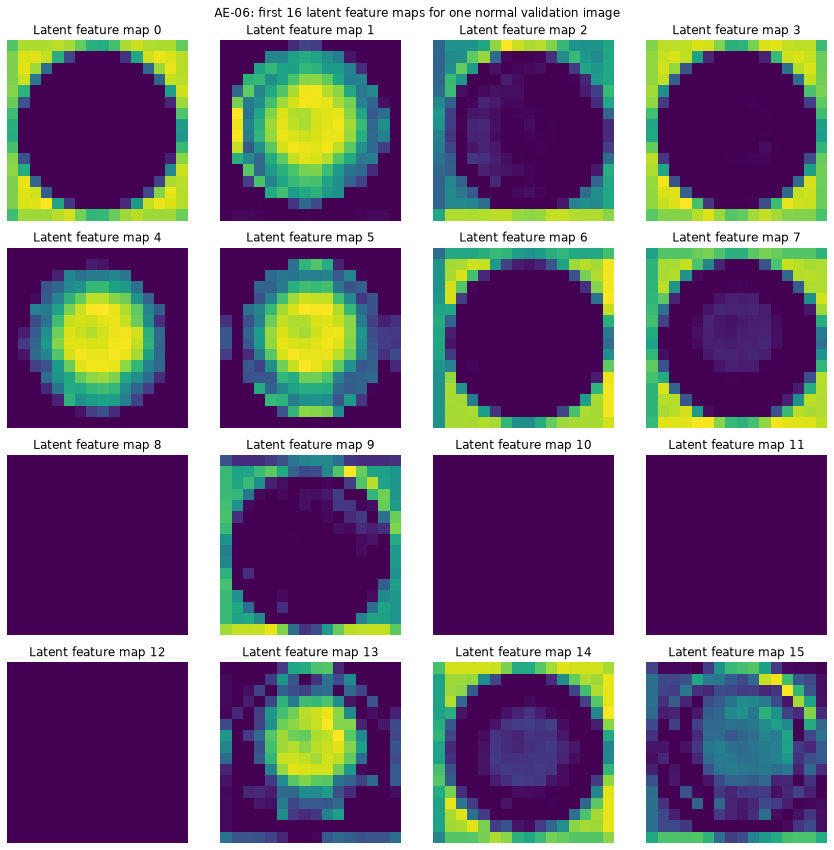

In [126]:
AE06_MAX_EPOCHS = 200
AE06_INITIAL_LEARNING_RATE = 1e-3
AE06_LR_CHANGE_EPOCH = 150
AE06_REFINEMENT_LEARNING_RATE = 1e-4
RETRAIN_AE06 = False  # True deliberately retrains and replaces the checkpoint.
AE06_CHECKPOINT_PATH = MODELS_DIR / 'ae06_conv_autoencoder16.pt'
AE06_CHECKPOINT_CONFIG = {
    'architecture': 'ConvAutoencoder16',
    'seed': SEED + 6,
    'batch_size': BATCH_SIZE,
    'max_epochs': AE06_MAX_EPOCHS,
    'initial_learning_rate': AE06_INITIAL_LEARNING_RATE,
    'learning_rate_change_epoch': AE06_LR_CHANGE_EPOCH,
    'refinement_learning_rate': AE06_REFINEMENT_LEARNING_RATE,
}

ae06_loader_generator = torch.Generator().manual_seed(SEED + 6)
train_loader_ae06 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=ae06_loader_generator,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)
optimizer_ae06 = torch.optim.Adam(
    model_ae06.parameters(), lr=AE06_INITIAL_LEARNING_RATE
)
history_ae06 = {'train_loss': [], 'validation_loss': [], 'learning_rate': []}
best_validation_loss_ae06 = float('inf')
best_epoch_ae06 = 0
best_state_ae06 = None
train_ae06 = RETRAIN_AE06 or not AE06_CHECKPOINT_PATH.exists()
if not train_ae06:
    metadata_ae06 = load_model_checkpoint(
        AE06_CHECKPOINT_PATH, model_ae06, expected_experiment='AE-06'
    )
    if metadata_ae06.get('config') != AE06_CHECKPOINT_CONFIG:
        raise ValueError(
            'AE-06 checkpoint settings differ from this notebook. '
            'Set RETRAIN_AE06=True only if replacement is intended.'
        )
    history_ae06 = metadata_ae06['history']
    best_validation_loss_ae06 = metadata_ae06['best_validation_loss']
    best_epoch_ae06 = metadata_ae06['best_epoch']
    best_state_ae06 = {
        key: value.detach().cpu().clone()
        for key, value in model_ae06.state_dict().items()
    }
else:
    print('Training AE-06 because retraining was requested or no checkpoint exists.')

for epoch in (range(1, AE06_MAX_EPOCHS + 1) if train_ae06 else []):
    if epoch == AE06_LR_CHANGE_EPOCH + 1:
        for parameter_group in optimizer_ae06.param_groups:
            parameter_group['lr'] = AE06_REFINEMENT_LEARNING_RATE

    model_ae06.train()
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader_ae06:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer_ae06.zero_grad()
        loss = criterion(model_ae06(images), images)
        loss.backward()
        optimizer_ae06.step()
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model_ae06.eval()
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model_ae06(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    current_learning_rate = optimizer_ae06.param_groups[0]['lr']
    history_ae06['train_loss'].append(train_loss)
    history_ae06['validation_loss'].append(validation_loss)
    history_ae06['learning_rate'].append(current_learning_rate)

    if validation_loss < best_validation_loss_ae06:
        best_validation_loss_ae06 = validation_loss
        best_epoch_ae06 = epoch
        best_state_ae06 = {
            key: value.detach().cpu().clone()
            for key, value in model_ae06.state_dict().items()
        }

    if epoch == 1 or epoch % 10 == 0:
        print(
            f'Epoch {epoch:03d}: train={train_loss:.6f}, '
            f'validation={validation_loss:.6f}, lr={current_learning_rate:.0e}'
        )

model_ae06.load_state_dict(best_state_ae06)
if train_ae06:
    save_model_checkpoint(
        AE06_CHECKPOINT_PATH, model_ae06,
        metadata={
            'experiment': 'AE-06',
            'config': AE06_CHECKPOINT_CONFIG,
            'best_epoch': best_epoch_ae06,
            'best_validation_loss': best_validation_loss_ae06,
            'history': history_ae06,
        },
    )
print(f'AE-06 best epoch: {best_epoch_ae06}')
print(f'AE-06 best validation MSE: {best_validation_loss_ae06:.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history_ae06['train_loss'], label='train')
plt.plot(history_ae06['validation_loss'], label='validation')
plt.axvline(
    AE06_LR_CHANGE_EPOCH, color='grey', linestyle='--',
    label='learning rate: 1e-3 -> 1e-4'
)
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('AE-06: stronger-compression training trajectory')
plt.legend()
plt.show()

show_reconstructions(model_ae06, validation_loader, experiment_name='AE-06', count=3)

# Uncomment to see sample latent space
show_latent_space(model_ae06, validation_loader, experiment_name='AE-06')


AE-06 validation-score mean: 0.000553
AE-06 validation-score median: 0.000530
AE-06 validation-score maximum: 0.000769
AE-06 frozen 95th-percentile threshold: 0.000747
AE-06 empirical validation false-positive rate: 7.1% (3 of 42)


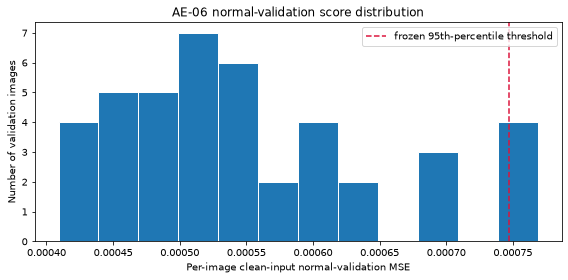

In [91]:
# Freeze AE-06 clean-input scoring and its normal-validation threshold.
AE06_SCORE_NAME = 'AE-06 stronger compression (clean-input scoring)'
validation_scores_ae06, _, _ = clean_reconstruction_scores(model_ae06, validation_loader)
validation_threshold_ae06 = np.percentile(validation_scores_ae06, THRESHOLD_PERCENTILE)
validation_predictions_ae06 = validation_scores_ae06 > validation_threshold_ae06

print(f'AE-06 validation-score mean: {validation_scores_ae06.mean():.6f}')
print(f'AE-06 validation-score median: {np.median(validation_scores_ae06):.6f}')
print(f'AE-06 validation-score maximum: {validation_scores_ae06.max():.6f}')
print(f'AE-06 frozen 95th-percentile threshold: {validation_threshold_ae06:.6f}')
print(
    'AE-06 empirical validation false-positive rate: '
    f'{validation_predictions_ae06.mean():.1%} '
    f'({validation_predictions_ae06.sum()} of {len(validation_predictions_ae06)})'
)

plt.figure(figsize=(8, 4))
plt.hist(validation_scores_ae06, bins=12, edgecolor='white')
plt.axvline(
    validation_threshold_ae06, color='crimson', linestyle='--',
    label='frozen 95th-percentile threshold'
)
plt.xlabel('Per-image clean-input normal-validation MSE')
plt.ylabel('Number of validation images')
plt.title('AE-06 normal-validation score distribution')
plt.legend()
plt.tight_layout()
plt.show()


### 12.1 AE-06 Bottle evaluation

The next cell evaluates AE-06 using clean-input MSE and its validation threshold. Because we designed AE-06 after examining earlier Bottle test errors, this is a useful follow-up comparison rather than a completely unseen final test.


AE-06 stronger compression (clean-input scoring)
Frozen validation threshold: 0.000747
Image AUROC: 0.8770
PR-AUC: 0.9586
Balanced accuracy: 0.7889
Good: 16 correct / 4 false alarms; anomalies: 49 detected / 14 missed
              precision    recall  f1-score   support

        good       0.53      0.80      0.64        20
     anomaly       0.92      0.78      0.84        63

    accuracy                           0.78        83
   macro avg       0.73      0.79      0.74        83
weighted avg       0.83      0.78      0.80        83



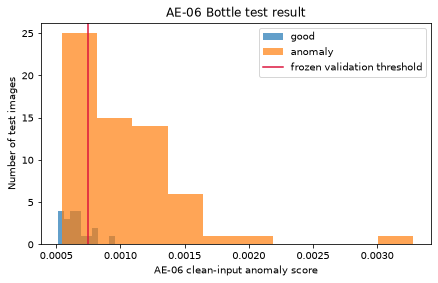

In [92]:
RUN_AE06_TEST_EVALUATION = True  # Learning follow-up; run once after AE-06 validation.

if RUN_AE06_TEST_EVALUATION:
    ae06_test_scores, ae06_test_labels, ae06_test_paths = clean_reconstruction_scores(
        model_ae06, test_loader
    )
    ae06_test_predictions = (ae06_test_scores > validation_threshold_ae06).astype(int)

    ae06_true_negatives = int(((ae06_test_labels == 0) & (ae06_test_predictions == 0)).sum())
    ae06_false_positives = int(((ae06_test_labels == 0) & (ae06_test_predictions == 1)).sum())
    ae06_true_positives = int(((ae06_test_labels == 1) & (ae06_test_predictions == 1)).sum())
    ae06_false_negatives = int(((ae06_test_labels == 1) & (ae06_test_predictions == 0)).sum())

    print(AE06_SCORE_NAME)
    print(f'Frozen validation threshold: {validation_threshold_ae06:.6f}')
    print(f'Image AUROC: {roc_auc_score(ae06_test_labels, ae06_test_scores):.4f}')
    print(f'PR-AUC: {average_precision_score(ae06_test_labels, ae06_test_scores):.4f}')
    print(
        'Balanced accuracy: '
        f'{balanced_accuracy_score(ae06_test_labels, ae06_test_predictions):.4f}'
    )
    print(
        f'Good: {ae06_true_negatives} correct / {ae06_false_positives} false alarms; '
        f'anomalies: {ae06_true_positives} detected / {ae06_false_negatives} missed'
    )
    print(classification_report(
        ae06_test_labels, ae06_test_predictions,
        target_names=['good', 'anomaly'], zero_division=0
    ))

    plt.figure(figsize=(7, 4))
    plt.hist(ae06_test_scores[ae06_test_labels == 0], alpha=.7, label='good')
    plt.hist(ae06_test_scores[ae06_test_labels == 1], alpha=.7, label='anomaly')
    plt.axvline(
        validation_threshold_ae06, color='crimson',
        label='frozen validation threshold'
    )
    plt.xlabel('AE-06 clean-input anomaly score')
    plt.ylabel('Number of test images')
    plt.title('AE-06 Bottle test result')
    plt.legend()
    plt.show()
else:
    print('AE-06 reused-test evaluation remains disabled.')


### 12.2 Result and decision

AE-06 selected epoch 199 with validation MSE 0.000553. On Bottle it achieved AUROC 0.8770, PR-AUC 0.9586, and balanced accuracy 0.7889, detecting 49 of 63 defects with 4 false alarms among 20 good images. This is a large improvement over AE-04, so stronger compression looks promising. AE-07 uses the same architecture but changes the random seed, training length, and learning-rate schedule, so it is a related longer run rather than an exact comparison of one change.


## 12.3 How AE-06 reconstructs defects

This figure shows how AE-06 reconstructs nine defective Bottle images, balanced across all three defect types. Each example contains the resized input with the known defect boundary, the reconstruction, and the pixel-error map. The title shows whether the validation threshold marked that image as `DETECTED` or `MISSED`.

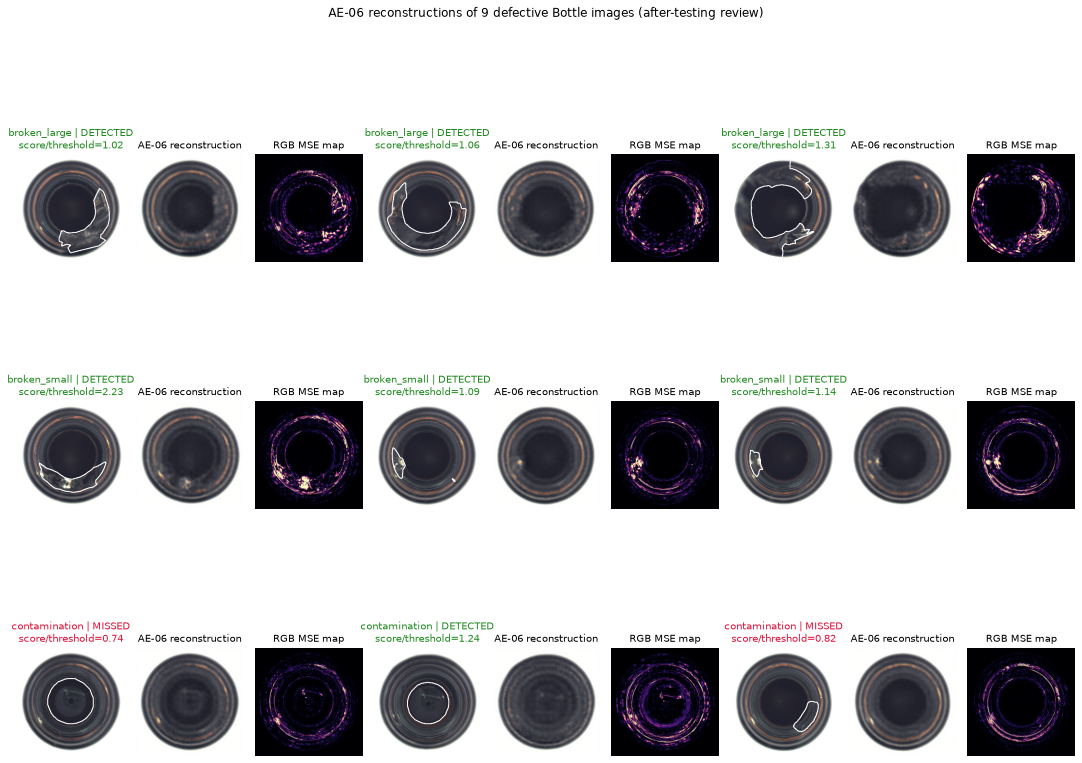

,filename,defect_type,decision,score,threshold
0,000.png,broken_large,DETECTED,0.000765,0.000747
1,007.png,broken_large,DETECTED,0.000790,0.000747
2,003.png,broken_large,DETECTED,0.000978,0.000747
3,012.png,broken_small,DETECTED,0.001668,0.000747
4,011.png,broken_small,DETECTED,0.000814,0.000747
5,014.png,broken_small,DETECTED,0.000855,0.000747
6,009.png,contamination,MISSED,0.000554,0.000747
7,010.png,contamination,DETECTED,0.000924,0.000747
8,019.png,contamination,MISSED,0.000611,0.000747


decision,DETECTED,MISSED,Total
defect_type,,,
broken_large,3,0,3
broken_small,3,0,3
contamination,1,2,3
Total,7,2,9


In [133]:
import pandas as pd
from PIL import Image

AE06_DEFECT_EXAMPLE_COUNT = 9

ae06_per_image_results = pd.DataFrame({
    'path': [str(path) for path in ae06_test_paths],
    'label': ae06_test_labels.astype(int),
    'score': ae06_test_scores,
    'detected': ae06_test_predictions.astype(bool),
})
ae06_defect_metadata = bottle_test[
    ['path', 'defect_type', 'mask_path']
].copy()
ae06_defect_metadata['path'] = ae06_defect_metadata['path'].astype(str)
ae06_per_image_results = ae06_per_image_results.merge(
    ae06_defect_metadata, on='path', how='left', validate='one_to_one'
)
ae06_defect_results = ae06_per_image_results[
    ae06_per_image_results['label'].eq(1)
].copy()

defect_types = sorted(ae06_defect_results['defect_type'].unique())
examples_per_type = AE06_DEFECT_EXAMPLE_COUNT // len(defect_types)
extra_examples = AE06_DEFECT_EXAMPLE_COUNT % len(defect_types)
selected_groups = []
for type_index, defect_type in enumerate(defect_types):
    requested_count = examples_per_type + int(type_index < extra_examples)
    type_candidates = ae06_defect_results[
        ae06_defect_results['defect_type'].eq(defect_type)
    ]
    selected_groups.append(type_candidates.sample(
        n=requested_count, random_state=SEED + 600 + type_index
    ))

ae06_selected_defects = pd.concat(selected_groups, ignore_index=True)
assert len(ae06_selected_defects) == AE06_DEFECT_EXAMPLE_COUNT

selected_manifest = (
    bottle_test.assign(path=bottle_test['path'].astype(str))
    .set_index('path')
    .loc[ae06_selected_defects['path']]
    .reset_index()
)
selected_dataset = MVTecImageDataset(selected_manifest, transform=image_transform)
selected_loader = DataLoader(
    selected_dataset, batch_size=AE06_DEFECT_EXAMPLE_COUNT, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
selected_images, selected_labels, selected_paths = next(iter(selected_loader))
assert [str(path) for path in selected_paths] == ae06_selected_defects['path'].tolist()

model_ae06.eval()
with torch.inference_mode():
    selected_reconstructions = model_ae06(
        selected_images.to(DEVICE, non_blocking=PIN_MEMORY)
    ).cpu()
selected_error_maps = (selected_reconstructions - selected_images).square().mean(dim=1)
error_vmax = float(np.quantile(selected_error_maps.numpy(), 0.99))

EXAMPLES_PER_ROW = 3
plot_rows = int(np.ceil(AE06_DEFECT_EXAMPLE_COUNT / EXAMPLES_PER_ROW))
plot_columns = EXAMPLES_PER_ROW * 3  # input, reconstruction, and error
figure, axes = plt.subplots(
    plot_rows, plot_columns, figsize=(15, 4 * plot_rows), squeeze=False
)
error_axes = []
for example_index, example in ae06_selected_defects.reset_index(drop=True).iterrows():
    row = example_index // EXAMPLES_PER_ROW
    first_column = (example_index % EXAMPLES_PER_ROW) * 3
    input_axis = axes[row, first_column]
    reconstruction_axis = axes[row, first_column + 1]
    error_axis = axes[row, first_column + 2]

    input_axis.imshow(selected_images[example_index].permute(1, 2, 0))
    with Image.open(example['mask_path']) as mask_image:
        resized_mask = mask_image.resize(
            (IMAGE_SIZE, IMAGE_SIZE), resample=Image.Resampling.NEAREST
        )
        binary_mask = np.asarray(resized_mask) > 0
    input_axis.contour(binary_mask, levels=[0.5], colors='white', linewidths=1.0)

    reconstruction_axis.imshow(
        selected_reconstructions[example_index].permute(1, 2, 0)
    )
    error_image = error_axis.imshow(
        selected_error_maps[example_index], cmap='magma', vmin=0, vmax=error_vmax
    )
    error_axes.append(error_axis)

    decision = 'DETECTED' if example['detected'] else 'MISSED'
    decision_colour = 'forestgreen' if example['detected'] else 'crimson'
    input_axis.set_title(
        f"{example['defect_type']} | {decision}\n"
        f"score/threshold={example['score'] / validation_threshold_ae06:.2f}",
        color=decision_colour, fontsize=10,
    )
    reconstruction_axis.set_title('AE-06 reconstruction', fontsize=10)
    error_axis.set_title('RGB MSE map', fontsize=10)
    input_axis.axis('off')
    reconstruction_axis.axis('off')
    error_axis.axis('off')

# Hide unused three-axis blocks if the example count is not divisible by the row size.
for unused_index in range(AE06_DEFECT_EXAMPLE_COUNT, plot_rows * EXAMPLES_PER_ROW):
    unused_row = unused_index // EXAMPLES_PER_ROW
    unused_first_column = (unused_index % EXAMPLES_PER_ROW) * 3
    for axis in axes[unused_row, unused_first_column:unused_first_column + 3]:
        axis.set_visible(False)

# figure.colorbar(
#     error_image, ax=error_axes, fraction=0.012, pad=0.01,
#     label='Per-pixel mean squared RGB error',
# )
figure.suptitle(
    'AE-06 reconstructions of 9 defective Bottle images (after-testing review)', y=1.005
)
plt.tight_layout()
plt.show()

ae06_selected_defects['filename'] = ae06_selected_defects['path'].map(
    lambda path: Path(path).name
)
ae06_selected_defects['decision'] = np.where(
    ae06_selected_defects['detected'], 'DETECTED', 'MISSED'
)
display(ae06_selected_defects[
    ['filename', 'defect_type', 'decision', 'score']
].assign(threshold=validation_threshold_ae06))
display(pd.crosstab(
    ae06_selected_defects['defect_type'], ae06_selected_defects['decision'],
    margins=True, margins_name='Total'
))


## 13. AE-07: longer AE-06 training

AE-07 is a longer version of the AE-06 idea. It keeps the `128 x 16 x 16` architecture, clean-reconstruction task, batch size 16, and Adam optimiser. It starts from new random weights, trains for up to 400 epochs, and changes the learning rate from `1e-3` to `1e-4` after epoch 200.

The run completes all 400 epochs while saving the checkpoint with the lowest validation MSE. We avoided early stopping because the loss fluctuated and could improve again later.

With 167 training images and batch size 16, each epoch has about 11 model updates. AE-07 therefore allows about 4,400 updates compared with about 2,200 for AE-06. Because the seed and learning-rate schedule also changed, we cannot say that training length alone caused the result.

**Question.** Can this longer AE-06-style run further reduce normal-validation reconstruction error, and does that translate into better Bottle test separation?


Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae07_conv_autoencoder16.pt
AE-07 epochs completed: 400
AE-07 best epoch: 399
AE-07 best validation MSE: 0.000529


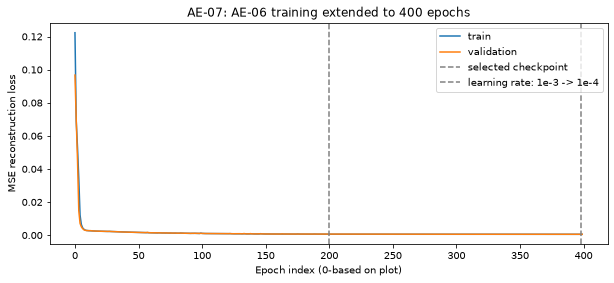

In [94]:
AE07_MAX_EPOCHS = 400
AE07_BATCH_SIZE = 16
AE07_INITIAL_LEARNING_RATE = 1e-3
AE07_LR_CHANGE_EPOCH = 200
AE07_REFINEMENT_LEARNING_RATE = 1e-4
RETRAIN_AE07 = False  # True deliberately retrains and replaces the checkpoint.
AE07_CHECKPOINT_PATH = MODELS_DIR / 'ae07_conv_autoencoder16.pt'
AE07_CHECKPOINT_CONFIG = {
    'architecture': 'ConvAutoencoder16',
    'seed': SEED + 7,
    'batch_size': AE07_BATCH_SIZE,
    'max_epochs': AE07_MAX_EPOCHS,
    'initial_learning_rate': AE07_INITIAL_LEARNING_RATE,
    'learning_rate_change_epoch': AE07_LR_CHANGE_EPOCH,
    'refinement_learning_rate': AE07_REFINEMENT_LEARNING_RATE,
}

torch.manual_seed(SEED + 7)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 7)
model_ae07 = ConvAutoencoder16().to(DEVICE)
optimizer_ae07 = torch.optim.Adam(
    model_ae07.parameters(), lr=AE07_INITIAL_LEARNING_RATE
)

ae07_loader_generator = torch.Generator().manual_seed(SEED + 7)
train_loader_ae07 = DataLoader(
    train_dataset, batch_size=AE07_BATCH_SIZE, shuffle=True,
    generator=ae07_loader_generator, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
)
history_ae07 = {'train_loss': [], 'validation_loss': [], 'learning_rate': []}
best_validation_loss_ae07 = float('inf')
best_epoch_ae07 = 0
best_state_ae07 = None
train_ae07 = RETRAIN_AE07 or not AE07_CHECKPOINT_PATH.exists()
if not train_ae07:
    metadata_ae07 = load_model_checkpoint(
        AE07_CHECKPOINT_PATH, model_ae07, expected_experiment='AE-07'
    )
    if metadata_ae07.get('config') != AE07_CHECKPOINT_CONFIG:
        raise ValueError(
            'AE-07 checkpoint settings differ from this notebook. '
            'Set RETRAIN_AE07=True only if replacement is intended.'
        )
    history_ae07 = metadata_ae07['history']
    best_validation_loss_ae07 = metadata_ae07['best_validation_loss']
    best_epoch_ae07 = metadata_ae07['best_epoch']
    best_state_ae07 = {
        key: value.detach().cpu().clone()
        for key, value in model_ae07.state_dict().items()
    }
else:
    print('Training AE-07 because retraining was requested or no checkpoint exists.')

for epoch in (range(1, AE07_MAX_EPOCHS + 1) if train_ae07 else []):
    if epoch == AE07_LR_CHANGE_EPOCH + 1:
        for parameter_group in optimizer_ae07.param_groups:
            parameter_group['lr'] = AE07_REFINEMENT_LEARNING_RATE

    model_ae07.train()
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader_ae07:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer_ae07.zero_grad()
        loss = criterion(model_ae07(images), images)
        loss.backward()
        optimizer_ae07.step()
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model_ae07.eval()
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model_ae07(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    current_learning_rate = optimizer_ae07.param_groups[0]['lr']
    history_ae07['train_loss'].append(train_loss)
    history_ae07['validation_loss'].append(validation_loss)
    history_ae07['learning_rate'].append(current_learning_rate)

    if validation_loss < best_validation_loss_ae07:
        best_validation_loss_ae07 = validation_loss
        best_epoch_ae07 = epoch
        best_state_ae07 = {
            key: value.detach().cpu().clone()
            for key, value in model_ae07.state_dict().items()
        }

    if epoch == 1 or epoch % 10 == 0:
        print(
            f'Epoch {epoch:03d}: train={train_loss:.6f}, '
            f'validation={validation_loss:.6f}, lr={current_learning_rate:.0e}'
        )

model_ae07.load_state_dict(best_state_ae07)
if train_ae07:
    save_model_checkpoint(
        AE07_CHECKPOINT_PATH, model_ae07,
        metadata={
            'experiment': 'AE-07',
            'config': AE07_CHECKPOINT_CONFIG,
            'best_epoch': best_epoch_ae07,
            'best_validation_loss': best_validation_loss_ae07,
            'history': history_ae07,
        },
    )
ae07_epochs_completed = len(history_ae07['train_loss'])
print(f'AE-07 epochs completed: {ae07_epochs_completed}')
print(f'AE-07 best epoch: {best_epoch_ae07}')
print(f'AE-07 best validation MSE: {best_validation_loss_ae07:.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history_ae07['train_loss'], label='train')
plt.plot(history_ae07['validation_loss'], label='validation')
plt.axvline(best_epoch_ae07 - 1, color='grey', linestyle='--', label='selected checkpoint')
plt.xlabel('Epoch index (0-based on plot)')
plt.ylabel('MSE reconstruction loss')
plt.axvline(
    AE07_LR_CHANGE_EPOCH, color='grey', linestyle='--',
    label='learning rate: 1e-3 -> 1e-4'
)
plt.title('AE-07: AE-06 training extended to 400 epochs')
plt.legend()
plt.show()


Input shape:  (1, 3, 256, 256) (196,608 values)
Latent shape: (1, 128, 16, 16) (32,768 values)
Value-count compression: 6.00x


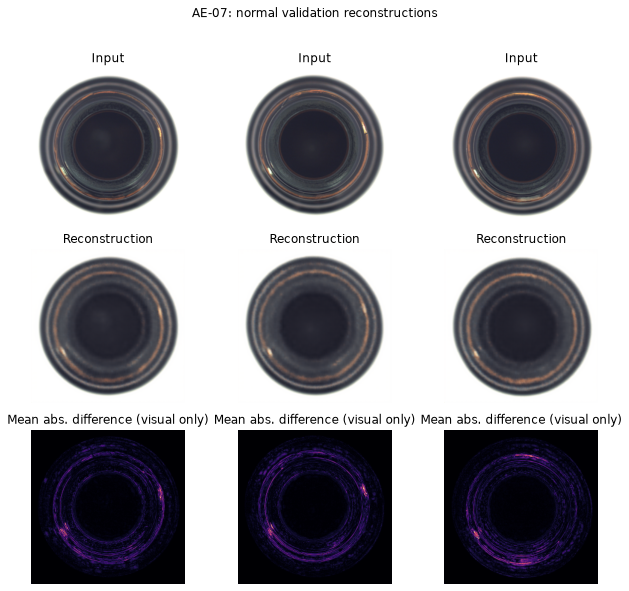

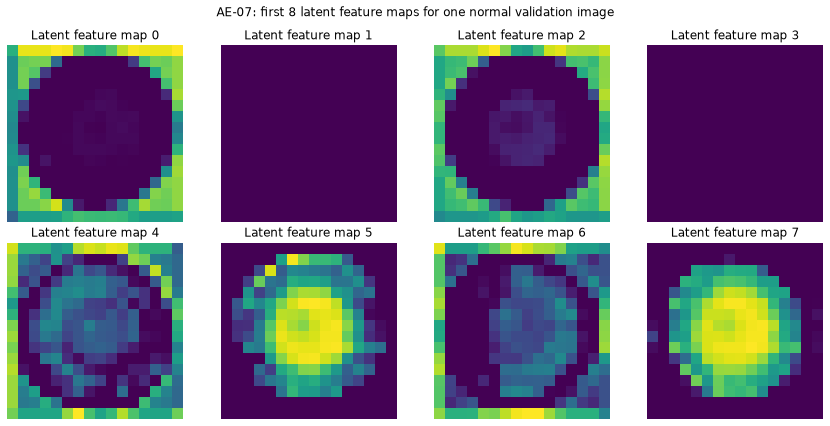

In [135]:

show_reconstructions(model_ae07, validation_loader, experiment_name='AE-07', count=3)
show_latent_space(model_ae07, validation_loader, experiment_name='AE-07', channels_to_show=8)


AE-07 validation-score mean: 0.000529
AE-07 validation-score median: 0.000508
AE-07 validation-score maximum: 0.000730
AE-07 frozen 95th-percentile threshold: 0.000700
AE-07 empirical validation false-positive rate: 7.1% (3 of 42)


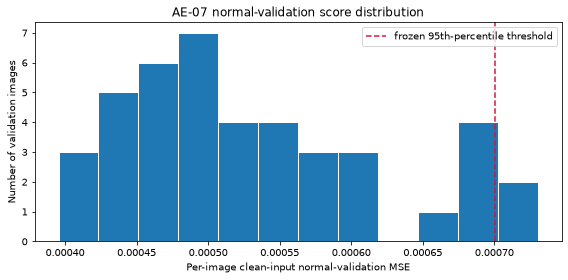

In [96]:
# Freeze AE-07 clean-input scoring and its normal-validation threshold.
AE07_SCORE_NAME = 'AE-07 longer AE-06 training (clean-input scoring)'
validation_scores_ae07, _, _ = clean_reconstruction_scores(model_ae07, validation_loader)
validation_threshold_ae07 = np.percentile(validation_scores_ae07, THRESHOLD_PERCENTILE)
validation_predictions_ae07 = validation_scores_ae07 > validation_threshold_ae07

print(f'AE-07 validation-score mean: {validation_scores_ae07.mean():.6f}')
print(f'AE-07 validation-score median: {np.median(validation_scores_ae07):.6f}')
print(f'AE-07 validation-score maximum: {validation_scores_ae07.max():.6f}')
print(f'AE-07 frozen 95th-percentile threshold: {validation_threshold_ae07:.6f}')
print(
    'AE-07 empirical validation false-positive rate: '
    f'{validation_predictions_ae07.mean():.1%} '
    f'({validation_predictions_ae07.sum()} of {len(validation_predictions_ae07)})'
)

plt.figure(figsize=(8, 4))
plt.hist(validation_scores_ae07, bins=12, edgecolor='white')
plt.axvline(
    validation_threshold_ae07, color='crimson', linestyle='--',
    label='frozen 95th-percentile threshold'
)
plt.xlabel('Per-image clean-input normal-validation MSE')
plt.ylabel('Number of validation images')
plt.title('AE-07 normal-validation score distribution')
plt.legend()
plt.tight_layout()
plt.show()


### 13.1 AE-07 Bottle evaluation

The next cell evaluates AE-07 using clean-input MSE and its validation threshold. Like AE-06, it was designed after seeing earlier Bottle results, so it is a follow-up comparison.


AE-07 longer AE-06 training (clean-input scoring)
Frozen validation threshold: 0.000700
Image AUROC: 0.8341
PR-AUC: 0.9453
Balanced accuracy: 0.7663
Good: 17 correct / 3 false alarms; anomalies: 43 detected / 20 missed
              precision    recall  f1-score   support

        good       0.46      0.85      0.60        20
     anomaly       0.93      0.68      0.79        63

    accuracy                           0.72        83
   macro avg       0.70      0.77      0.69        83
weighted avg       0.82      0.72      0.74        83



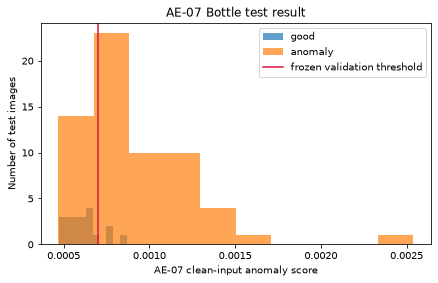

In [97]:
RUN_AE07_TEST_EVALUATION = True  # Run once after training and validation cells above.

if RUN_AE07_TEST_EVALUATION:
    test_dataset_ae07 = MVTecImageDataset(bottle_test, transform=image_transform)
    test_loader_ae07 = DataLoader(
        test_dataset_ae07, batch_size=AE07_BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    ae07_test_scores, ae07_test_labels, ae07_test_paths = clean_reconstruction_scores(
        model_ae07, test_loader_ae07
    )
    ae07_test_predictions = (ae07_test_scores > validation_threshold_ae07).astype(int)

    ae07_true_negatives = int(((ae07_test_labels == 0) & (ae07_test_predictions == 0)).sum())
    ae07_false_positives = int(((ae07_test_labels == 0) & (ae07_test_predictions == 1)).sum())
    ae07_true_positives = int(((ae07_test_labels == 1) & (ae07_test_predictions == 1)).sum())
    ae07_false_negatives = int(((ae07_test_labels == 1) & (ae07_test_predictions == 0)).sum())

    print(AE07_SCORE_NAME)
    print(f'Frozen validation threshold: {validation_threshold_ae07:.6f}')
    print(f'Image AUROC: {roc_auc_score(ae07_test_labels, ae07_test_scores):.4f}')
    print(f'PR-AUC: {average_precision_score(ae07_test_labels, ae07_test_scores):.4f}')
    print(
        'Balanced accuracy: '
        f'{balanced_accuracy_score(ae07_test_labels, ae07_test_predictions):.4f}'
    )
    print(
        f'Good: {ae07_true_negatives} correct / {ae07_false_positives} false alarms; '
        f'anomalies: {ae07_true_positives} detected / {ae07_false_negatives} missed'
    )
    print(classification_report(
        ae07_test_labels, ae07_test_predictions,
        target_names=['good', 'anomaly'], zero_division=0
    ))

    plt.figure(figsize=(7, 4))
    plt.hist(ae07_test_scores[ae07_test_labels == 0], alpha=.7, label='good')
    plt.hist(ae07_test_scores[ae07_test_labels == 1], alpha=.7, label='anomaly')
    plt.axvline(
        validation_threshold_ae07, color='crimson',
        label='frozen validation threshold'
    )
    plt.xlabel('AE-07 clean-input anomaly score')
    plt.ylabel('Number of test images')
    plt.title('AE-07 Bottle test result')
    plt.legend()
    plt.show()
else:
    print('AE-07 reused-test evaluation remains disabled.')


### 13.2 Result and decision

AE-07 completed 400 epochs and selected epoch 399, with validation MSE 0.000529 and threshold 0.000700. This MSE is 4.3% lower than AE-06's, so normal reconstruction improved. However, Bottle performance declined: AUROC fell from 0.8770 to 0.8341, PR-AUC from 0.9586 to 0.9453, and balanced accuracy from 0.7889 to 0.7663. AE-07 detected 43 of 63 defects compared with AE-06's 49. Better reconstruction therefore did not produce better defect detection. Because AE-07 also changed the random seed and learning-rate schedule, training length alone may not explain the difference. AE-06 remains the strongest autoencoder result.


## 14. AE-08: stronger compression with masked restoration

AE-08 combines our two main autoencoder ideas: AE-05's masked-region restoration task and AE-06's smaller `128 x 16 x 16` representation. We designed it after seeing earlier Bottle results, so it is another follow-up comparison on the same data.

AE-08 reuses AE-05's normal-only task: two `32 x 32` average-colour patches, a loss containing 75% hidden-region MSE and 25% whole-image MSE, batch size 16, Adam at `1e-3`, and up to 150 epochs. We keep the checkpoint with the lowest hidden-region validation loss. The architecture and random seed both differ from AE-05, so one run cannot prove that compression alone caused any change.

As with AE-05, we evaluate the same AE-08 model in two ways: clean-input whole-image MSE and masked-restoration top-1% error. Each gets its own 95th-percentile threshold from normal validation images.

**Question.** Does the smaller latent representation help the masked-restoration model learn normal Bottle structure that separates defects more clearly?


In [98]:
AE08_PATCH_SIZE = 32
AE08_PATCHES_PER_IMAGE = 2
AE08_MASKED_LOSS_WEIGHT = 0.75
AE08_RESTORATION_TOP_FRACTION = 0.01

def apply_mean_cutout_ae08(images, generator):
    """Hide two square regions using each image's mean colour."""
    corrupted_images = images.clone()
    mask = torch.zeros(
        (len(images), 1, images.shape[-2], images.shape[-1]),
        device=images.device,
    )
    height, width = images.shape[-2:]
    for image_index in range(len(images)):
        fill_value = images[image_index].mean(dim=(1, 2), keepdim=True)
        for _ in range(AE08_PATCHES_PER_IMAGE):
            top = int(torch.randint(
                height - AE08_PATCH_SIZE + 1, (1,), generator=generator
            ).item())
            left = int(torch.randint(
                width - AE08_PATCH_SIZE + 1, (1,), generator=generator
            ).item())
            bottom, right = top + AE08_PATCH_SIZE, left + AE08_PATCH_SIZE
            corrupted_images[image_index, :, top:bottom, left:right] = fill_value
            mask[image_index, :, top:bottom, left:right] = 1.0
    return corrupted_images, mask

def restoration_losses_ae08(reconstruction, clean_images, mask):
    """Return weighted task loss and its masked/full MSE parts."""
    squared_error = (reconstruction - clean_images).pow(2)
    masked_mse = (
        (squared_error * mask).sum() / (mask.sum() * clean_images.shape[1])
    )
    full_mse = squared_error.mean()
    task_loss = (
        AE08_MASKED_LOSS_WEIGHT * masked_mse
        + (1 - AE08_MASKED_LOSS_WEIGHT) * full_mse
    )
    return task_loss, masked_mse, full_mse

def paired_patch_schedule_ae08(height, width):
    """Pair grid patches so every pixel is hidden exactly once."""
    if height % AE08_PATCH_SIZE or width % AE08_PATCH_SIZE:
        raise ValueError('Image dimensions must be divisible by AE08_PATCH_SIZE.')
    positions = [
        (top, left)
        for top in range(0, height, AE08_PATCH_SIZE)
        for left in range(0, width, AE08_PATCH_SIZE)
    ]
    if len(positions) % AE08_PATCHES_PER_IMAGE:
        raise ValueError('Patch grid must divide evenly into masked versions.')
    if AE08_PATCHES_PER_IMAGE != 2:
        raise ValueError('AE-08 scoring is fixed to two patches per version.')
    half = len(positions) // 2
    return list(zip(positions[:half], positions[half:]))

def masked_restoration_scores_ae08(model_to_score, loader):
    """Return top-1% full-coverage restoration scores and anomaly maps."""
    model_to_score.eval()
    scores, labels, paths, anomaly_maps = [], [], [], []
    with torch.inference_mode():
        for images, batch_labels, batch_paths in loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            height, width = images.shape[-2:]
            schedule = paired_patch_schedule_ae08(height, width)
            error_sum = torch.zeros(
                (len(images), height, width), device=images.device
            )
            coverage = torch.zeros((height, width), device=images.device)
            fill_values = images.mean(dim=(2, 3), keepdim=True)
            for patch_pair in schedule:
                masked_inputs = images.clone()
                spatial_mask = torch.zeros(
                    (height, width), device=images.device
                )
                for top, left in patch_pair:
                    bottom = top + AE08_PATCH_SIZE
                    right = left + AE08_PATCH_SIZE
                    masked_inputs[:, :, top:bottom, left:right] = fill_values
                    spatial_mask[top:bottom, left:right] = 1.0
                expected_area = (
                    AE08_PATCHES_PER_IMAGE * AE08_PATCH_SIZE**2
                )
                if int(spatial_mask.sum().item()) != expected_area:
                    raise RuntimeError('AE-08 scoring patches must not overlap.')
                reconstructions = model_to_score(masked_inputs)
                rgb_mse = (reconstructions - images).square().mean(dim=1)
                error_sum += rgb_mse * spatial_mask
                coverage += spatial_mask
            if not torch.all(coverage > 0):
                raise RuntimeError('Every scored pixel must be covered.')
            anomaly_map = error_sum / coverage.unsqueeze(0)
            top_pixel_count = max(
                1, int(np.ceil(
                    anomaly_map[0].numel() * AE08_RESTORATION_TOP_FRACTION
                )),
            )
            batch_scores = torch.topk(
                anomaly_map.flatten(start_dim=1), top_pixel_count, dim=1
            ).values.mean(dim=1)
            scores.extend(batch_scores.cpu().numpy())
            labels.extend(batch_labels.numpy())
            paths.extend(batch_paths)
            anomaly_maps.append(anomaly_map.cpu().numpy())
    return (
        np.asarray(scores), np.asarray(labels), paths,
        np.concatenate(anomaly_maps),
    )


Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae08_compressed_masked_restoration.pt
AE-08 best epoch by masked validation loss: 149
AE-08 best masked validation MSE: 0.003031


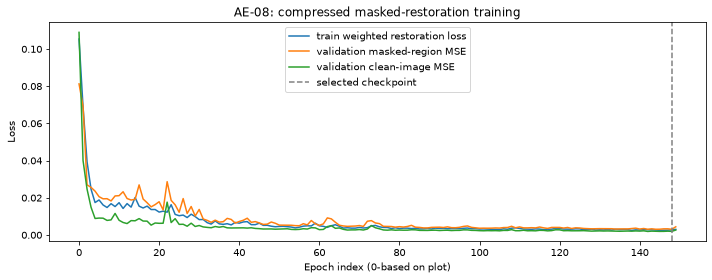

In [99]:
AE08_MAX_EPOCHS = 150
AE08_BATCH_SIZE = 16
AE08_LEARNING_RATE = 1e-3
RETRAIN_AE08 = False  # True deliberately retrains and replaces the checkpoint.
AE08_CHECKPOINT_PATH = MODELS_DIR / 'ae08_compressed_masked_restoration.pt'
AE08_CHECKPOINT_CONFIG = {
    'architecture': 'ConvAutoencoder16',
    'seed': SEED + 8,
    'batch_size': AE08_BATCH_SIZE,
    'max_epochs': AE08_MAX_EPOCHS,
    'learning_rate': AE08_LEARNING_RATE,
    'patch_size': AE08_PATCH_SIZE,
    'patches_per_image': AE08_PATCHES_PER_IMAGE,
    'masked_loss_weight': AE08_MASKED_LOSS_WEIGHT,
    'restoration_top_fraction': AE08_RESTORATION_TOP_FRACTION,
}

torch.manual_seed(SEED + 8)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 8)
model_ae08 = ConvAutoencoder16().to(DEVICE)
optimizer_ae08 = torch.optim.Adam(model_ae08.parameters(), lr=AE08_LEARNING_RATE)

ae08_loader_generator = torch.Generator().manual_seed(SEED + 8)
train_loader_ae08 = DataLoader(
    train_dataset, batch_size=AE08_BATCH_SIZE, shuffle=True,
    generator=ae08_loader_generator, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
)
history_ae08 = {
    'train_task_loss': [], 'masked_validation_loss': [],
    'clean_validation_mse': [],
}
best_masked_validation_loss_ae08 = float('inf')
best_epoch_ae08 = 0
best_state_ae08 = None
train_mask_generator_ae08 = torch.Generator().manual_seed(SEED + 801)
train_ae08 = RETRAIN_AE08 or not AE08_CHECKPOINT_PATH.exists()
if not train_ae08:
    metadata_ae08 = load_model_checkpoint(
        AE08_CHECKPOINT_PATH, model_ae08, expected_experiment='AE-08'
    )
    if metadata_ae08.get('config') != AE08_CHECKPOINT_CONFIG:
        raise ValueError(
            'AE-08 checkpoint settings differ from this notebook. '
            'Set RETRAIN_AE08=True only if replacement is intended.'
        )
    history_ae08 = metadata_ae08['history']
    best_masked_validation_loss_ae08 = metadata_ae08[
        'best_masked_validation_loss'
    ]
    best_epoch_ae08 = metadata_ae08['best_epoch']
    best_state_ae08 = {
        key: value.detach().cpu().clone()
        for key, value in model_ae08.state_dict().items()
    }
else:
    print('Training AE-08 because retraining was requested or no checkpoint exists.')

for epoch in (range(1, AE08_MAX_EPOCHS + 1) if train_ae08 else []):
    model_ae08.train()
    train_loss_total, train_image_count = 0.0, 0
    for clean_images, _, _ in train_loader_ae08:
        clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY)
        masked_inputs, mask = apply_mean_cutout_ae08(
            clean_images, train_mask_generator_ae08
        )
        optimizer_ae08.zero_grad()
        reconstruction = model_ae08(masked_inputs)
        task_loss, _, _ = restoration_losses_ae08(
            reconstruction, clean_images, mask
        )
        task_loss.backward()
        optimizer_ae08.step()
        train_loss_total += task_loss.item() * len(clean_images)
        train_image_count += len(clean_images)

    # Resetting this seed makes validation masks identical in every epoch.
    validation_mask_generator_ae08 = torch.Generator().manual_seed(SEED + 802)
    model_ae08.eval()
    masked_loss_total = clean_mse_total = 0.0
    validation_image_count = 0
    with torch.inference_mode():
        for clean_images, _, _ in validation_loader:
            clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY)
            masked_inputs, mask = apply_mean_cutout_ae08(
                clean_images, validation_mask_generator_ae08
            )
            masked_reconstruction = model_ae08(masked_inputs)
            _, masked_mse, _ = restoration_losses_ae08(
                masked_reconstruction, clean_images, mask
            )
            clean_reconstruction = model_ae08(clean_images)
            clean_mse = criterion(clean_reconstruction, clean_images)
            masked_loss_total += masked_mse.item() * len(clean_images)
            clean_mse_total += clean_mse.item() * len(clean_images)
            validation_image_count += len(clean_images)

    train_task_loss = train_loss_total / train_image_count
    masked_validation_loss = masked_loss_total / validation_image_count
    clean_validation_mse = clean_mse_total / validation_image_count
    history_ae08['train_task_loss'].append(train_task_loss)
    history_ae08['masked_validation_loss'].append(masked_validation_loss)
    history_ae08['clean_validation_mse'].append(clean_validation_mse)

    if masked_validation_loss < best_masked_validation_loss_ae08:
        best_masked_validation_loss_ae08 = masked_validation_loss
        best_epoch_ae08 = epoch
        best_state_ae08 = {
            key: value.detach().cpu().clone()
            for key, value in model_ae08.state_dict().items()
        }

    if epoch == 1 or epoch % 10 == 0:
        print(
            f'Epoch {epoch:03d}: train task={train_task_loss:.6f}, '
            f'masked validation={masked_validation_loss:.6f}, '
            f'clean validation MSE={clean_validation_mse:.6f}'
        )

model_ae08.load_state_dict(best_state_ae08)
if train_ae08:
    save_model_checkpoint(
        AE08_CHECKPOINT_PATH, model_ae08,
        metadata={
            'experiment': 'AE-08',
            'config': AE08_CHECKPOINT_CONFIG,
            'best_epoch': best_epoch_ae08,
            'best_masked_validation_loss': best_masked_validation_loss_ae08,
            'history': history_ae08,
        },
    )
print(f'AE-08 best epoch by masked validation loss: {best_epoch_ae08}')
print(f'AE-08 best masked validation MSE: {best_masked_validation_loss_ae08:.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history_ae08['train_task_loss'], label='train weighted restoration loss')
plt.plot(history_ae08['masked_validation_loss'], label='validation masked-region MSE')
plt.plot(history_ae08['clean_validation_mse'], label='validation clean-image MSE')
plt.axvline(best_epoch_ae08 - 1, color='grey', linestyle='--', label='selected checkpoint')
plt.xlabel('Epoch index (0-based on plot)')
plt.ylabel('Loss')
plt.title('AE-08: compressed masked-restoration training')
plt.legend()
plt.tight_layout()
plt.show()


AE-08 (clean-input scoring)
  validation mean: 0.001915
  frozen threshold: 0.002440
  validation false-positive rate: 7.1% (3 of 42)
AE-08 (masked-restoration scoring)
  validation mean: 0.071350
  frozen threshold: 0.087334
  validation false-positive rate: 7.1% (3 of 42)


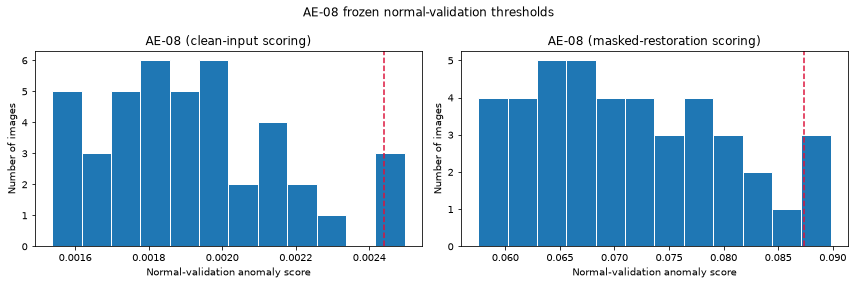

Input shape:  (1, 3, 256, 256) (196,608 values)
Latent shape: (1, 128, 16, 16) (32,768 values)
Value-count compression: 6.00x


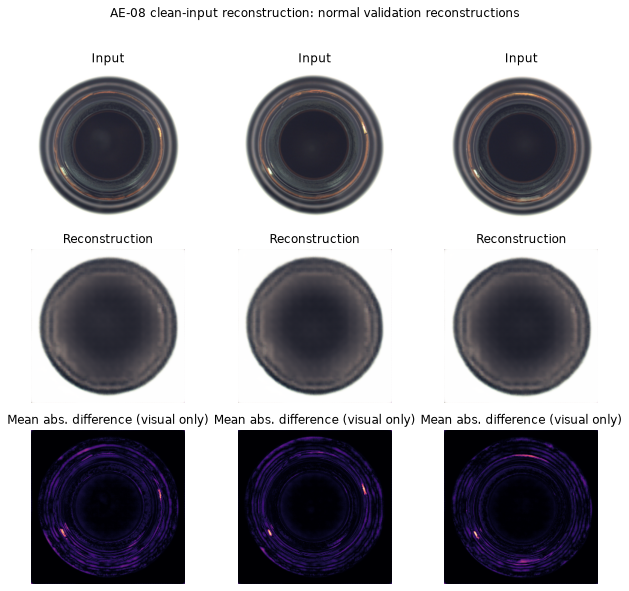

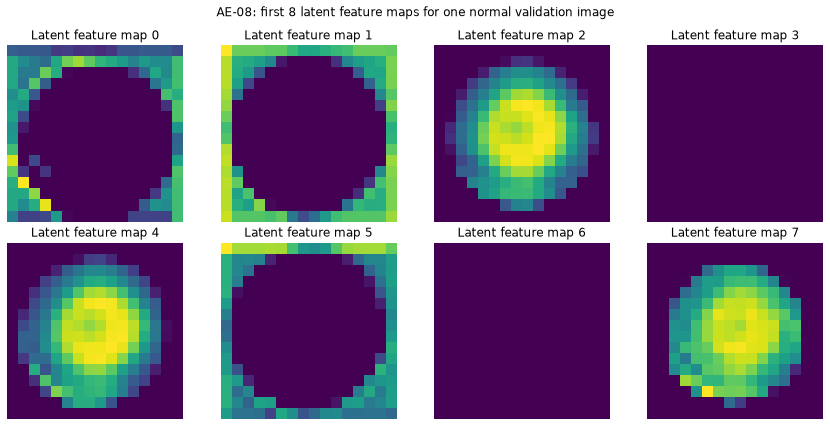

In [136]:
AE08_CLEAN_SCORE_NAME = 'AE-08 (clean-input scoring)'
AE08_RESTORATION_SCORE_NAME = 'AE-08 (masked-restoration scoring)'

validation_scores_ae08_clean, _, _ = clean_reconstruction_scores(
    model_ae08, validation_loader
)
(
    validation_scores_ae08_restoration, _, _,
    validation_maps_ae08_restoration,
) = masked_restoration_scores_ae08(model_ae08, validation_loader)

validation_thresholds_ae08 = {
    AE08_CLEAN_SCORE_NAME: np.percentile(
        validation_scores_ae08_clean, THRESHOLD_PERCENTILE
    ),
    AE08_RESTORATION_SCORE_NAME: np.percentile(
        validation_scores_ae08_restoration, THRESHOLD_PERCENTILE
    ),
}
validation_scores_by_protocol_ae08 = {
    AE08_CLEAN_SCORE_NAME: validation_scores_ae08_clean,
    AE08_RESTORATION_SCORE_NAME: validation_scores_ae08_restoration,
}

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (protocol_name, scores) in zip(
    axes, validation_scores_by_protocol_ae08.items()
):
    threshold = validation_thresholds_ae08[protocol_name]
    predictions = scores > threshold
    print(protocol_name)
    print(f'  validation mean: {scores.mean():.6f}')
    print(f'  frozen threshold: {threshold:.6f}')
    print(
        f'  validation false-positive rate: {predictions.mean():.1%} '
        f'({predictions.sum()} of {len(predictions)})'
    )
    axis.hist(scores, bins=12, edgecolor='white')
    axis.axvline(threshold, color='crimson', linestyle='--')
    axis.set_title(protocol_name)
    axis.set_xlabel('Normal-validation anomaly score')
    axis.set_ylabel('Number of images')
figure.suptitle('AE-08 frozen normal-validation thresholds')
plt.tight_layout()
plt.show()

show_reconstructions(
    model_ae08, validation_loader, experiment_name='AE-08 clean-input reconstruction', count=3
)
show_latent_space(model_ae08, validation_loader, experiment_name='AE-08', channels_to_show=8)


### 14.1 AE-08 Bottle evaluation

We selected the AE-08 checkpoint and both thresholds using normal validation images, then evaluated it on Bottle. Because AE-08 was designed after earlier Bottle results were known, its result is a follow-up comparison rather than a completely unseen final test.



AE-08 (clean-input scoring)
Frozen validation threshold: 0.002440
Image AUROC: 0.7833
PR-AUC: 0.9325
Balanced accuracy: 0.7357
Good: 18 correct / 2 false alarms; anomalies: 36 detected / 27 missed
              precision    recall  f1-score   support

        good       0.40      0.90      0.55        20
     anomaly       0.95      0.57      0.71        63

    accuracy                           0.65        83
   macro avg       0.67      0.74      0.63        83
weighted avg       0.82      0.65      0.67        83



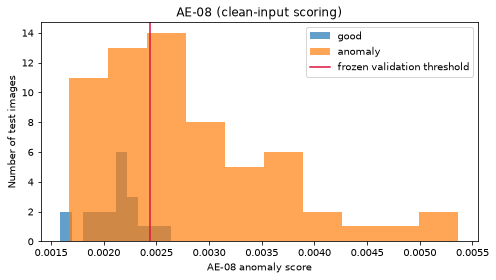


AE-08 (masked-restoration scoring)
Frozen validation threshold: 0.087334
Image AUROC: 0.8222
PR-AUC: 0.9473
Balanced accuracy: 0.7925
Good: 19 correct / 1 false alarms; anomalies: 40 detected / 23 missed
              precision    recall  f1-score   support

        good       0.45      0.95      0.61        20
     anomaly       0.98      0.63      0.77        63

    accuracy                           0.71        83
   macro avg       0.71      0.79      0.69        83
weighted avg       0.85      0.71      0.73        83



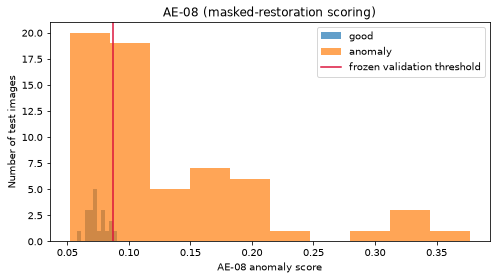

In [101]:
RUN_AE08_BOTTLE_EVALUATION = True

if RUN_AE08_BOTTLE_EVALUATION:
    test_dataset_ae08 = MVTecImageDataset(bottle_test, transform=image_transform)
    test_loader_ae08 = DataLoader(
        test_dataset_ae08, batch_size=AE08_BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    ae08_protocols = {
        AE08_CLEAN_SCORE_NAME: clean_reconstruction_scores,
        AE08_RESTORATION_SCORE_NAME: masked_restoration_scores_ae08,
    }
    ae08_test_results = {}

    for protocol_name, scoring_function in ae08_protocols.items():
        scoring_output = scoring_function(model_ae08, test_loader_ae08)
        scores, labels, paths = scoring_output[:3]
        threshold = validation_thresholds_ae08[protocol_name]
        predictions = (scores > threshold).astype(int)
        true_negatives = int(((labels == 0) & (predictions == 0)).sum())
        false_positives = int(((labels == 0) & (predictions == 1)).sum())
        true_positives = int(((labels == 1) & (predictions == 1)).sum())
        false_negatives = int(((labels == 1) & (predictions == 0)).sum())
        ae08_test_results[protocol_name] = {
            'scores': scores, 'labels': labels, 'paths': paths,
            'predictions': predictions, 'threshold': threshold,
        }

        print(f'\n{protocol_name}')
        print(f'Frozen validation threshold: {threshold:.6f}')
        print(f'Image AUROC: {roc_auc_score(labels, scores):.4f}')
        print(f'PR-AUC: {average_precision_score(labels, scores):.4f}')
        print(
            'Balanced accuracy: '
            f'{balanced_accuracy_score(labels, predictions):.4f}'
        )
        print(
            f'Good: {true_negatives} correct / {false_positives} false alarms; '
            f'anomalies: {true_positives} detected / {false_negatives} missed'
        )
        print(classification_report(
            labels, predictions, target_names=['good', 'anomaly'],
            zero_division=0,
        ))

        plt.figure(figsize=(7, 4))
        plt.hist(scores[labels == 0], alpha=.7, label='good')
        plt.hist(scores[labels == 1], alpha=.7, label='anomaly')
        plt.axvline(threshold, color='crimson', label='frozen validation threshold')
        plt.xlabel('AE-08 anomaly score')
        plt.ylabel('Number of test images')
        plt.title(protocol_name)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print('AE-08 Bottle evaluation is disabled. Freeze validation choices first.')


### 14.2 AE-08 result and decision

AE-08 selected epoch 149 using masked validation MSE 0.003031. Its clean-input validation mean and threshold were 0.001915 and 0.002440; its masked-restoration validation mean and threshold were 0.071350 and 0.087334. Both thresholds flagged 3 of 42 normal validation images (7.1%).

| AE-08 scoring method | AUROC | PR-AUC | Balanced accuracy | Good: correct / false alarms | Defects: detected / missed |
| --- | ---: | ---: | ---: | ---: | ---: |
| Clean-input scoring | 0.7833 | 0.9325 | 0.7357 | 18 / 2 | 36 / 27 |
| Masked-restoration scoring | **0.8222** | **0.9473** | **0.7925** | **19 / 1** | **40 / 23** |

AE-08 masked-restoration scoring improved clearly over AE-05: AUROC rose from 0.6841 to 0.8222, PR-AUC from 0.8996 to 0.9473, balanced accuracy from 0.7131 to 0.7925, and detected defects from 30 to 40 while keeping one false alarm. Stronger compression may have helped the restoration task, but AE-08 also used a different random seed, so this run cannot prove that compression was the only reason.

AE-08 clean-input scoring improved slightly over AE-05 in AUROC but detected fewer defects at its threshold. Masked-restoration scoring is therefore the more useful AE-08 result. Compared with AE-06, AE-08 has slightly higher balanced accuracy and fewer false alarms, while AE-06 has better AUROC, PR-AUC, and defect detection. We keep both results because they show different trade-offs.


## 15. AE-09: narrower autoencoder with 24x compression

In [102]:
class ConvAutoencoderNarrow(nn.Module):
    """Four-stage autoencoder with a 32 x 16 x 16 bottleneck."""

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 32, 4, stride=2, padding=1),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, images):
        return self.decoder(self.encoder(images))

In [103]:
torch.manual_seed(SEED + 9)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 9)
model_ae09 = ConvAutoencoderNarrow().to(DEVICE)

sample_images_ae09, _, _ = next(iter(validation_loader))
with torch.inference_mode():
    sample_latent_ae09 = model_ae09.encoder(sample_images_ae09[:1].to(DEVICE))
    sample_reconstruction_ae09 = model_ae09(sample_images_ae09[:1].to(DEVICE))

assert tuple(sample_latent_ae09.shape[1:]) == (32, 16, 16)
assert sample_reconstruction_ae09.shape == sample_images_ae09[:1].shape
ae09_parameter_count = sum(parameter.numel() for parameter in model_ae09.parameters())
ae09_input_values = sample_images_ae09[0].numel()
ae09_latent_values = sample_latent_ae09[0].numel()
print(model_ae09)
print(f'Trainable parameters: {ae09_parameter_count:,}')
print(f'Input shape:  {tuple(sample_images_ae09[:1].shape)} ({ae09_input_values:,} values)')
print(f'Latent shape: {tuple(sample_latent_ae09.shape)} ({ae09_latent_values:,} values)')
print(f'Value-count compression: {ae09_input_values / ae09_latent_values:.2f}x')

ConvAutoencoderNarrow(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)
Trainable parameters: 462,307
Input shape:  (1, 3, 256, 256) (196,608 values)
Latent shape: (1, 32, 16, 16) (8,192 values)
Value-count compression: 

AE-09 keeps AE-06's four-stage, `16 x 16` spatial representation but reduces the final encoder width from 128 to 32 channels. This changes the bottleneck from 32,768 to 8,192 values, increasing value-count compression from 6x to 24x. We otherwise match AE-06's clean-reconstruction task and training schedule so that bottleneck width is the main intended change. The narrower encoder and decoder boundary also reduces parameter count, so this experiment tests both bottleneck compression and nearby model capacity.

**Question.** Does a `32 x 16 x 16` bottleneck make defects harder to reconstruct without losing too much normal Bottle detail?

Loaded checkpoint: /home/ali/projects/anomaly-detection/models/ae09_conv_autoencoder_narrow.pt
AE-09 best epoch: 200
AE-09 best validation MSE: 0.000790


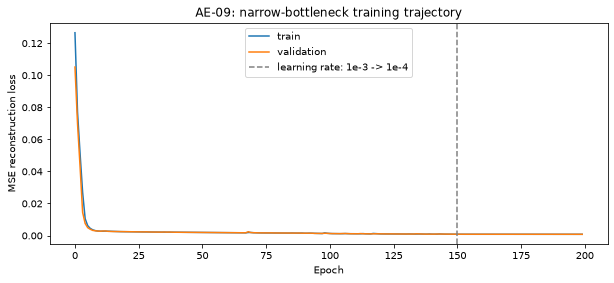

Input shape:  (1, 3, 256, 256) (196,608 values)
Latent shape: (1, 32, 16, 16) (8,192 values)
Value-count compression: 24.00x


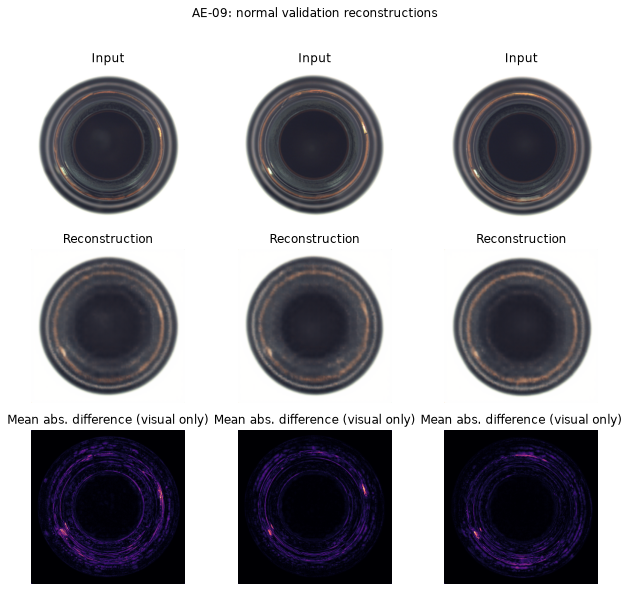

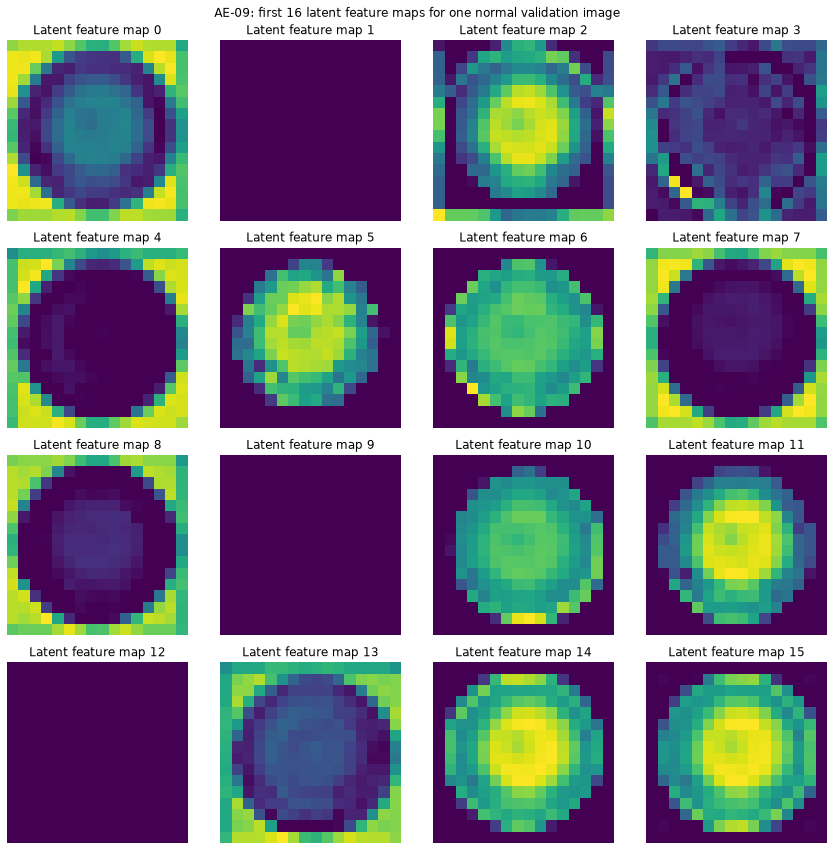

In [137]:
AE09_MAX_EPOCHS = 200
AE09_INITIAL_LEARNING_RATE = 1e-3
AE09_LR_CHANGE_EPOCH = 150
AE09_REFINEMENT_LEARNING_RATE = 1e-4
RETRAIN_AE09 = False  # True deliberately retrains and replaces the checkpoint.
AE09_CHECKPOINT_PATH = MODELS_DIR / 'ae09_conv_autoencoder_narrow.pt'
AE09_CHECKPOINT_CONFIG = {
    'architecture': 'ConvAutoencoderNarrow',
    'seed': SEED + 9,
    'batch_size': BATCH_SIZE,
    'max_epochs': AE09_MAX_EPOCHS,
    'initial_learning_rate': AE09_INITIAL_LEARNING_RATE,
    'learning_rate_change_epoch': AE09_LR_CHANGE_EPOCH,
    'refinement_learning_rate': AE09_REFINEMENT_LEARNING_RATE,
}

ae09_loader_generator = torch.Generator().manual_seed(SEED + 9)
train_loader_ae09 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=ae09_loader_generator,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)
optimizer_ae09 = torch.optim.Adam(model_ae09.parameters(), lr=AE09_INITIAL_LEARNING_RATE)
history_ae09 = {'train_loss': [], 'validation_loss': [], 'learning_rate': []}
best_validation_loss_ae09 = float('inf')
best_epoch_ae09 = 0
best_state_ae09 = None
train_ae09 = RETRAIN_AE09 or not AE09_CHECKPOINT_PATH.exists()

if not train_ae09:
    metadata_ae09 = load_model_checkpoint(
        AE09_CHECKPOINT_PATH, model_ae09, expected_experiment='AE-09'
    )
    if metadata_ae09.get('config') != AE09_CHECKPOINT_CONFIG:
        raise ValueError(
            'AE-09 checkpoint settings differ from this notebook. '
            'Set RETRAIN_AE09=True only if replacement is intended.'
        )
    history_ae09 = metadata_ae09['history']
    best_validation_loss_ae09 = metadata_ae09['best_validation_loss']
    best_epoch_ae09 = metadata_ae09['best_epoch']
    best_state_ae09 = {
        key: value.detach().cpu().clone()
        for key, value in model_ae09.state_dict().items()
    }
else:
    print('Training AE-09 because retraining was requested or no checkpoint exists.')

for epoch in (range(1, AE09_MAX_EPOCHS + 1) if train_ae09 else []):
    if epoch == AE09_LR_CHANGE_EPOCH + 1:
        for parameter_group in optimizer_ae09.param_groups:
            parameter_group['lr'] = AE09_REFINEMENT_LEARNING_RATE

    model_ae09.train()
    train_loss_total, train_image_count = 0.0, 0
    for images, _, _ in train_loader_ae09:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer_ae09.zero_grad()
        loss = criterion(model_ae09(images), images)
        loss.backward()
        optimizer_ae09.step()
        train_loss_total += loss.item() * len(images)
        train_image_count += len(images)

    model_ae09.eval()
    validation_loss_total, validation_image_count = 0.0, 0
    with torch.inference_mode():
        for images, _, _ in validation_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            validation_batch_loss = criterion(model_ae09(images), images)
            validation_loss_total += validation_batch_loss.item() * len(images)
            validation_image_count += len(images)

    train_loss = train_loss_total / train_image_count
    validation_loss = validation_loss_total / validation_image_count
    current_learning_rate = optimizer_ae09.param_groups[0]['lr']
    history_ae09['train_loss'].append(train_loss)
    history_ae09['validation_loss'].append(validation_loss)
    history_ae09['learning_rate'].append(current_learning_rate)

    if validation_loss < best_validation_loss_ae09:
        best_validation_loss_ae09 = validation_loss
        best_epoch_ae09 = epoch
        best_state_ae09 = {
            key: value.detach().cpu().clone()
            for key, value in model_ae09.state_dict().items()
        }

    if epoch == 1 or epoch % 10 == 0:
        print(
            f'Epoch {epoch:03d}: train={train_loss:.6f}, '
            f'validation={validation_loss:.6f}, lr={current_learning_rate:.0e}'
        )

model_ae09.load_state_dict(best_state_ae09)
if train_ae09:
    save_model_checkpoint(
        AE09_CHECKPOINT_PATH, model_ae09,
        metadata={
            'experiment': 'AE-09',
            'config': AE09_CHECKPOINT_CONFIG,
            'best_epoch': best_epoch_ae09,
            'best_validation_loss': best_validation_loss_ae09,
            'history': history_ae09,
        },
    )
print(f'AE-09 best epoch: {best_epoch_ae09}')
print(f'AE-09 best validation MSE: {best_validation_loss_ae09:.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history_ae09['train_loss'], label='train')
plt.plot(history_ae09['validation_loss'], label='validation')
plt.axvline(
    AE09_LR_CHANGE_EPOCH, color='grey', linestyle='--',
    label='learning rate: 1e-3 -> 1e-4'
)
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('AE-09: narrow-bottleneck training trajectory')
plt.legend()
plt.show()

show_reconstructions(model_ae09, validation_loader, experiment_name='AE-09', count=3)
show_latent_space(model_ae09, validation_loader, experiment_name='AE-09')

AE-09 validation-score mean: 0.000790
AE-09 validation-score median: 0.000773
AE-09 validation-score maximum: 0.001057
AE-09 frozen 95th-percentile threshold: 0.001028
AE-09 empirical validation false-positive rate: 7.1% (3 of 42)


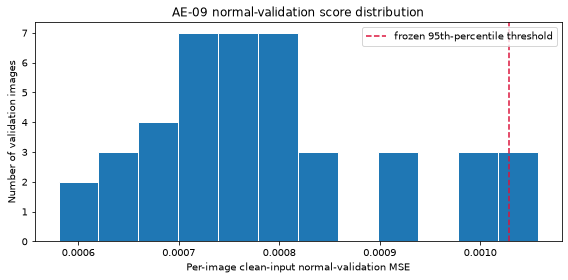

In [105]:
# Freeze AE-09 clean-input scoring and its normal-validation threshold.
AE09_SCORE_NAME = 'AE-09 narrow bottleneck (clean-input scoring)'
validation_scores_ae09, _, _ = clean_reconstruction_scores(model_ae09, validation_loader)
validation_threshold_ae09 = np.percentile(validation_scores_ae09, THRESHOLD_PERCENTILE)
validation_predictions_ae09 = validation_scores_ae09 > validation_threshold_ae09

print(f'AE-09 validation-score mean: {validation_scores_ae09.mean():.6f}')
print(f'AE-09 validation-score median: {np.median(validation_scores_ae09):.6f}')
print(f'AE-09 validation-score maximum: {validation_scores_ae09.max():.6f}')
print(f'AE-09 frozen 95th-percentile threshold: {validation_threshold_ae09:.6f}')
print(
    'AE-09 empirical validation false-positive rate: '
    f'{validation_predictions_ae09.mean():.1%} '
    f'({validation_predictions_ae09.sum()} of {len(validation_predictions_ae09)})'
)

plt.figure(figsize=(8, 4))
plt.hist(validation_scores_ae09, bins=12, edgecolor='white')
plt.axvline(
    validation_threshold_ae09, color='crimson', linestyle='--',
    label='frozen 95th-percentile threshold'
)
plt.xlabel('Per-image clean-input normal-validation MSE')
plt.ylabel('Number of validation images')
plt.title('AE-09 normal-validation score distribution')
plt.legend()
plt.tight_layout()
plt.show()

### 15.1 AE-09 Bottle evaluation

The next cell applies AE-09's normal-validation threshold to the Bottle test images and compares it with the earlier autoencoders.

AE-09 narrow bottleneck (clean-input scoring)
Frozen validation threshold: 0.001028
Image AUROC: 0.8222
PR-AUC: 0.9419
Balanced accuracy: 0.7163
Good: 15 correct / 5 false alarms; anomalies: 43 detected / 20 missed
              precision    recall  f1-score   support

        good       0.43      0.75      0.55        20
     anomaly       0.90      0.68      0.77        63

    accuracy                           0.70        83
   macro avg       0.66      0.72      0.66        83
weighted avg       0.78      0.70      0.72        83



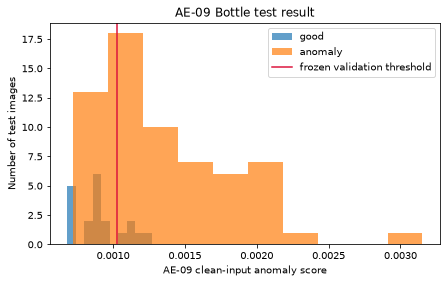

In [106]:
RUN_AE09_TEST_EVALUATION = True  # Set True only after freezing training and validation choices.

if RUN_AE09_TEST_EVALUATION:
    ae09_test_scores, ae09_test_labels, ae09_test_paths = clean_reconstruction_scores(
        model_ae09, test_loader
    )
    ae09_test_predictions = (ae09_test_scores > validation_threshold_ae09).astype(int)

    ae09_true_negatives = int(((ae09_test_labels == 0) & (ae09_test_predictions == 0)).sum())
    ae09_false_positives = int(((ae09_test_labels == 0) & (ae09_test_predictions == 1)).sum())
    ae09_true_positives = int(((ae09_test_labels == 1) & (ae09_test_predictions == 1)).sum())
    ae09_false_negatives = int(((ae09_test_labels == 1) & (ae09_test_predictions == 0)).sum())

    print(AE09_SCORE_NAME)
    print(f'Frozen validation threshold: {validation_threshold_ae09:.6f}')
    print(f'Image AUROC: {roc_auc_score(ae09_test_labels, ae09_test_scores):.4f}')
    print(f'PR-AUC: {average_precision_score(ae09_test_labels, ae09_test_scores):.4f}')
    print(
        'Balanced accuracy: '
        f'{balanced_accuracy_score(ae09_test_labels, ae09_test_predictions):.4f}'
    )
    print(
        f'Good: {ae09_true_negatives} correct / {ae09_false_positives} false alarms; '
        f'anomalies: {ae09_true_positives} detected / {ae09_false_negatives} missed'
    )
    print(classification_report(
        ae09_test_labels, ae09_test_predictions,
        target_names=['good', 'anomaly'], zero_division=0
    ))

    plt.figure(figsize=(7, 4))
    plt.hist(ae09_test_scores[ae09_test_labels == 0], alpha=.7, label='good')
    plt.hist(ae09_test_scores[ae09_test_labels == 1], alpha=.7, label='anomaly')
    plt.axvline(
        validation_threshold_ae09, color='crimson',
        label='frozen validation threshold'
    )
    plt.xlabel('AE-09 clean-input anomaly score')
    plt.ylabel('Number of test images')
    plt.title('AE-09 Bottle test result')
    plt.legend()
    plt.show()
else:
    print('AE-09 reused-test evaluation remains disabled.')

### 15.2 AE-09 result and decision

AE-09 selected epoch 200 with normal-validation MSE **0.000790** and a 95th-percentile threshold of **0.001028**. Its `32 x 16 x 16` bottleneck contains 8,192 values, giving 24x value-count compression compared with the 256 x 256 RGB input. On the Bottle test set, it achieved AUROC **0.8222**, PR-AUC **0.9419**, and balanced accuracy **0.7163**. It correctly accepted 15 of 20 good images and detected 43 of 63 defects, leaving 5 false alarms and 20 missed defects.

The narrower bottleneck did not improve on AE-06's 6x-compressed representation: AE-09 had lower AUROC (0.8222 vs 0.8770), lower PR-AUC (0.9419 vs 0.9586), lower balanced accuracy (0.7163 vs 0.7889), more false alarms (5 vs 4), and fewer detected defects (43 vs 49). It also reconstructed normal validation images less accurately than AE-06 (MSE 0.000790 vs 0.000553). This suggests that 24x compression removed useful normal Bottle detail without making defects sufficiently harder to reconstruct.

AE-09 is still informative negative evidence: compression helped when moving from the original 1.5x bottleneck to AE-06's 6x bottleneck, but increasing it to 24x did not continue that improvement. AE-09 also uses a fresh seed, so the result reflects the complete experiment rather than bottleneck width alone.

## 16. Experiment log and final conclusions

### 16.1 Experimental progression

All autoencoders learned from normal training images only. We used 42 normal validation images to select checkpoints and calculate thresholds, then used the Bottle test set to compare the models and guide later experiments.

| Experiment | Main change | Selected validation result | Outcome |
| --- | --- | ---: | --- |
| AE-01 | Three-stage clean autoencoder, 30 epochs | MSE 0.001073 at epoch 30 | Learning was still progressing. |
| AE-02 main continuation | Continue AE-01 to 100 epochs | MSE 0.000465 at epoch 97 | Large improvement; keep training. |
| AE-02 earlier restart | Independent 60-epoch restart | MSE 0.000627 at epoch 60 | Retained as a learning record but not directly comparable. |
| AE-03 | Continue the main trajectory to 150 epochs | MSE 0.000374 at epoch 150 | Further but slower improvement. |
| AE-04 | Continue to 200 epochs; reduce LR after epoch 150 | MSE 0.000366; threshold 0.000461 | Best validation reconstruction in the original trajectory, but weak anomaly separation. |
| AE-05 | New masked-region restoration task | Masked MSE 0.005139 at epoch 141 | Learned restoration; clean and masked scoring produced different trade-offs. |
| AE-06 (follow-up) | Add fourth downsampling stage; 128 x 16 x 16 latent (6x compression) | MSE 0.000553 at epoch 199; threshold 0.000747 | Best autoencoder ranking and defect count. |
| AE-07 (follow-up) | Fresh AE-06-style run for 400 epochs | MSE 0.000529 at epoch 399; threshold 0.000700 | Better normal reconstruction than AE-06, but worse anomaly separation. |
| AE-08 (follow-up) | Compressed architecture plus masked restoration | Masked MSE 0.003031 at epoch 149; masked threshold 0.087334 | Best autoencoder balanced accuracy and fewest false alarms. |
| AE-09 (follow-up) | Narrow final latent width to 32 channels; 32 x 16 x 16 latent (24x compression) | MSE 0.000790 at epoch 200; threshold 0.001028 | Excess compression reduced normal reconstruction quality and did not beat AE-06 detection. |

### 16.2 Bottle evaluation results

| Method | Evaluation stage | AUROC | PR-AUC | Balanced accuracy | Good correct / false alarms | Defects detected / missed |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| AE-04 clean reconstruction | First evaluation | 0.6167 | 0.8599 | 0.6405 | 18 / 2 | 24 / 39 |
| AE-05 clean-input scoring | First evaluation | 0.7627 | 0.9239 | 0.7663 | 17 / 3 | 43 / 20 |
| AE-05 masked-restoration scoring | First evaluation | 0.6841 | 0.8996 | 0.7131 | 19 / 1 | 30 / 33 |
| AE-06 stronger compression | Project evaluation | **0.8770** | **0.9586** | 0.7889 | 16 / 4 | **49 / 14** |
| AE-07 longer run | Project evaluation | 0.8341 | 0.9453 | 0.7663 | 17 / 3 | 43 / 20 |
| AE-08 clean-input scoring | Project evaluation | 0.7833 | 0.9325 | 0.7357 | 18 / 2 | 36 / 27 |
| AE-08 masked-restoration scoring | Project evaluation | 0.8222 | 0.9473 | **0.7925** | **19 / 1** | 40 / 23 |
| AE-09 narrow bottleneck | Project evaluation | 0.8222 | 0.9419 | 0.7163 | 15 / 5 | 43 / 20 |
| Frozen ResNet-18 + 5-NN baseline | Baseline | **0.9881** | **0.9960** | **0.9433** | **19 / 1** | **59 / 4** |

### 16.3 Conclusions

1. **Reconstruction quality alone was not a reliable detector-selection criterion.** AE-04 and AE-07 improved normal reconstruction without becoming the strongest anomaly detectors.
2. **Compression had a useful middle range.** Moving from the original 1.5x representation to AE-06's 6x representation improved detection substantially, but AE-09's 24x bottleneck did not improve further. AE-09 instead increased normal reconstruction error and produced more false alarms.
3. **Masked restoration benefited from the 6x-compressed architecture.** AE-08 masked scoring improved clearly over AE-05 and achieved the best autoencoder balanced accuracy, although AE-06 retained the best autoencoder AUROC, PR-AUC, and detected-defect count.
4. **Whole-image MSE can dilute local defects or reconstruct them successfully.** Notebook 04 therefore tests SSIM-based local error (`1 - SSIM`) with top-pixel aggregation. This changes only scoring, produces a spatial anomaly map, and stays separate from the AE-01 to AE-09 training progression.
5. **The frozen pretrained-feature baseline remains strongest.** It detected 59 of 63 defects with one false alarm and outperformed every student-designed autoencoder.

### 16.4 Limitations and final decision

Only Bottle, one main split, and mostly one seed per experiment were used. The 42-image normal validation set makes the 95th-percentile thresholds approximate. Differences in seeds and schedules also mean the experiments do not isolate architecture changes perfectly.

We stop extending the Bottle autoencoders here. AE-06 is retained as the strongest autoencoder for ranking and detecting defects; AE-08 masked restoration is retained when avoiding false alarms matters more. AE-09 shows that still narrower compression is not automatically better. Notebook 04 continues with an AE-06 SSIM scoring study, while a future extension could repeat the comparison on another product category.

## 17. Missed and detected defect examples for every autoencoder

Each figure is a **4 x 4 grid** containing four defective Bottle images: two false negatives (missed defects) and two true positives (detected defects), sampled reproducibly with seed 17. Row labels report the defect type, score, threshold, and decision.

For clean-reconstruction models, the columns are input, reconstruction, absolute reconstruction error, and the ground-truth defect overlay. For AE-05 and AE-08, which were trained with masked restoration, the columns instead show clean input, a reproducibly masked input, reconstruction from that masked input, and absolute error against the clean target. Their missed/detected decisions still use the full-coverage masked-restoration score defined earlier, not the single display mask.

AE-01 to AE-03 were not part of the original test table, so this review applies the same predeclared 95th-percentile normal-validation threshold rule to them. The cell reports that explicitly and does not use these extra test views to change any model or threshold.

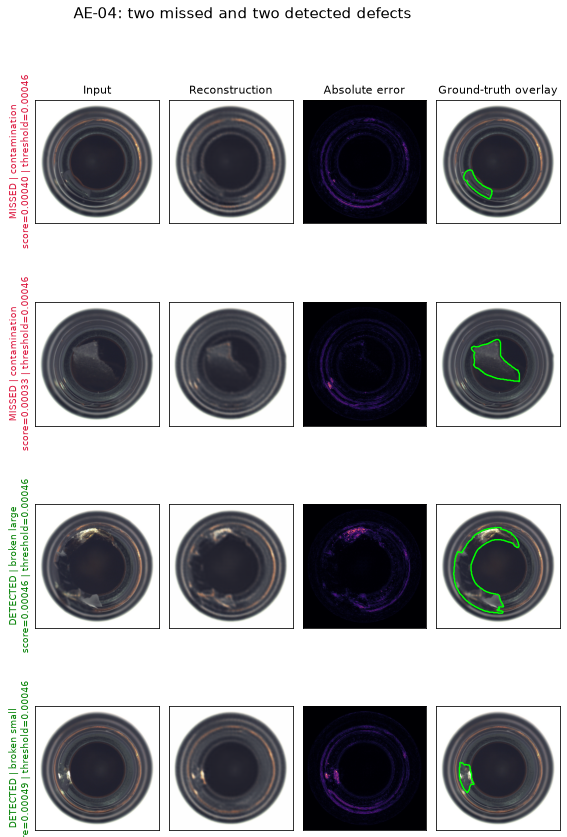

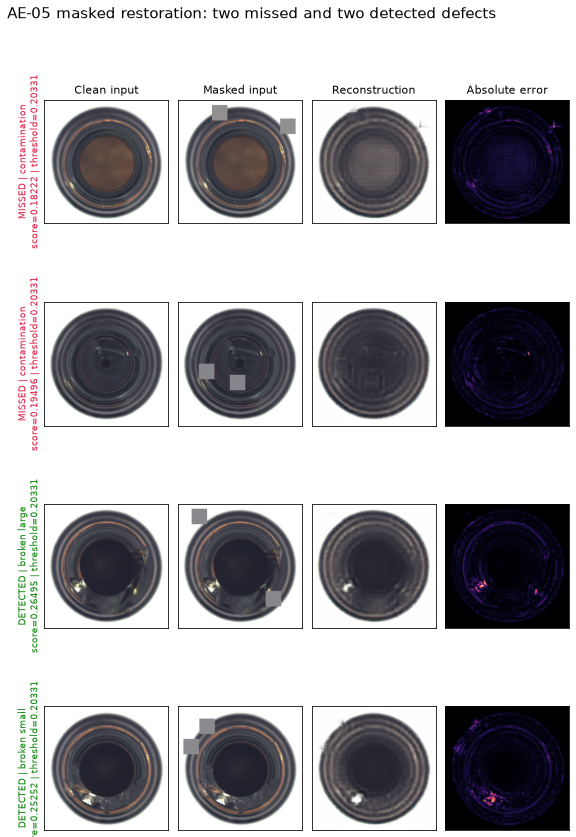

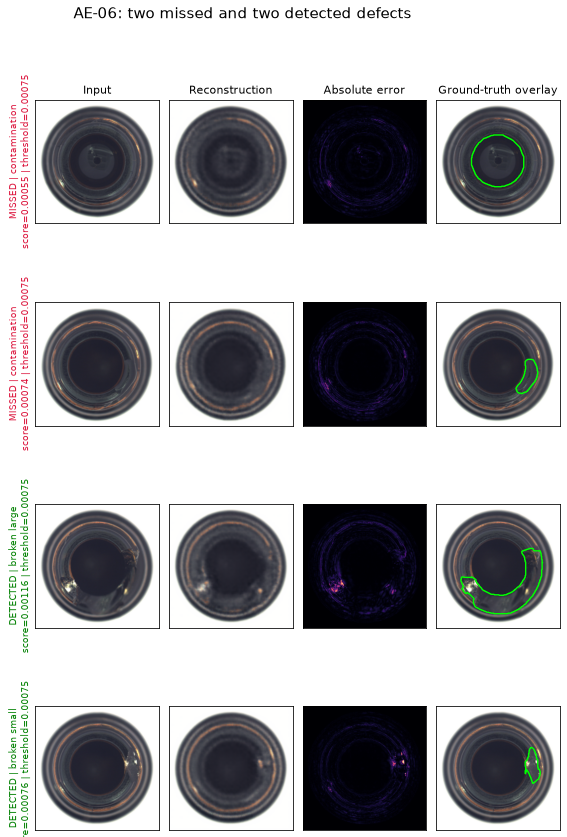

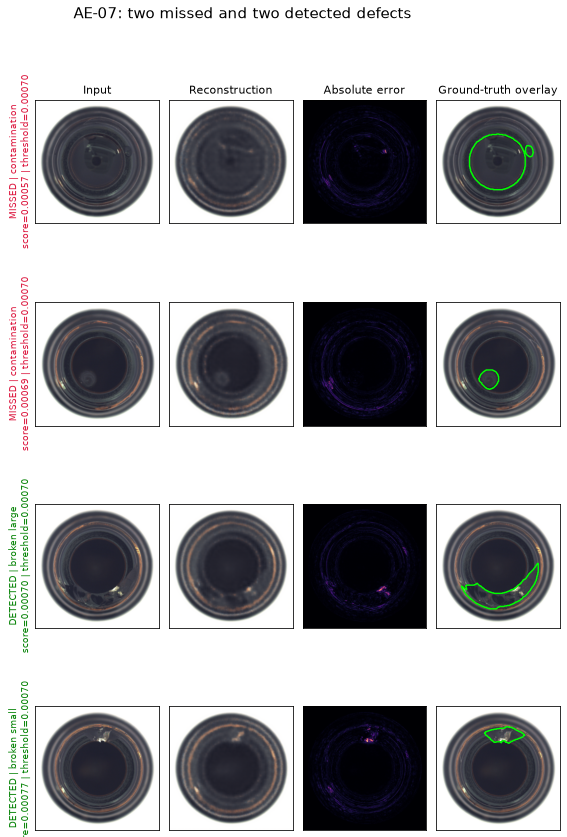

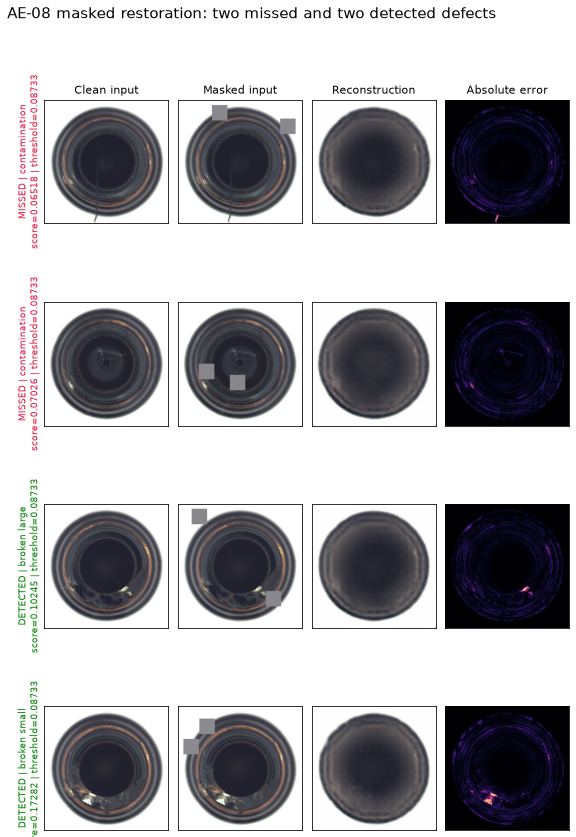

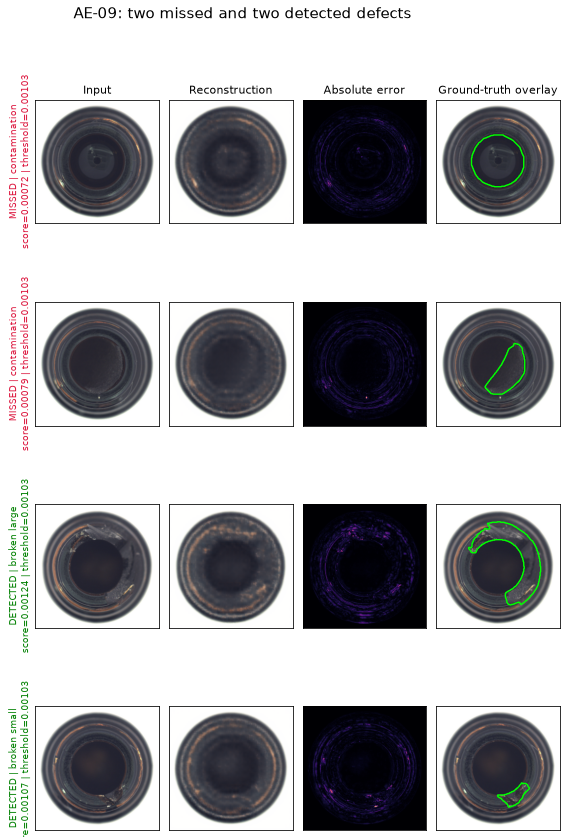

In [143]:
from PIL import Image

QUALITATIVE_SEED = 17
EXAMPLES_PER_DECISION = 2

def _normal_validation_threshold(model_to_score, scoring_function):
    validation_output = scoring_function(model_to_score, validation_loader)
    return np.percentile(validation_output[0], THRESHOLD_PERCENTILE)

# One frozen scoring protocol per trained model. AE-05 and AE-08 use the
# protocol that matches their masked-restoration training task.
qualitative_model_specs = [
    ('AE-04', model_ae04, clean_reconstruction_scores,
     validation_thresholds[AE04_SCORE_NAME], 'clean'),
    ('AE-05 masked restoration', model_ae05, masked_restoration_scores,
     validation_thresholds[AE05_RESTORATION_SCORE_NAME], 'masked_ae05'),
    ('AE-06', model_ae06, clean_reconstruction_scores,
     validation_threshold_ae06, 'clean'),
    ('AE-07', model_ae07, clean_reconstruction_scores,
     validation_threshold_ae07, 'clean'),
    ('AE-08 masked restoration', model_ae08, masked_restoration_scores_ae08,
     validation_thresholds_ae08[AE08_RESTORATION_SCORE_NAME], 'masked_ae08'),
    ('AE-09', model_ae09, clean_reconstruction_scores,
     validation_threshold_ae09, 'clean'),
]

def _ground_truth_mask_path(image_path):
    image_path = Path(image_path)
    # .../bottle/test/<defect>/<id>.png ->
    # .../bottle/ground_truth/<defect>/<id>_mask.png
    return (image_path.parents[2] / 'ground_truth' / image_path.parent.name
            / f'{image_path.stem}_mask.png')

def _load_resized_mask(image_path, output_size):
    mask_path = _ground_truth_mask_path(image_path)
    with Image.open(mask_path) as mask_image:
        mask_image = mask_image.convert('L').resize(
            (output_size, output_size), resample=Image.Resampling.NEAREST
        )
        return np.asarray(mask_image) > 0

def _display_masked_input(clean_batch, mode, seed):
    generator = torch.Generator().manual_seed(seed)
    if mode == 'masked_ae05':
        return apply_mean_cutout(
            clean_batch, PATCH_SIZE, PATCHES_PER_IMAGE, generator
        )[0]
    if mode == 'masked_ae08':
        return apply_mean_cutout_ae08(clean_batch, generator)[0]
    return clean_batch

def show_missed_and_detected_grid(
    experiment_name, model_to_show, scoring_function, threshold, input_mode,
):
    if threshold is None:
        threshold = _normal_validation_threshold(model_to_show, scoring_function)

    scoring_output = scoring_function(model_to_show, test_loader)
    scores, labels, paths = scoring_output[:3]
    predictions = (scores > threshold).astype(int)
    labels = np.asarray(labels).astype(int)

    missed = np.flatnonzero((labels == 1) & (predictions == 0))
    detected = np.flatnonzero((labels == 1) & (predictions == 1))
    if len(missed) < EXAMPLES_PER_DECISION or len(detected) < EXAMPLES_PER_DECISION:
        raise ValueError(
            f'{experiment_name} needs at least {EXAMPLES_PER_DECISION} missed and '
            f'{EXAMPLES_PER_DECISION} detected defects; found '
            f'{len(missed)} and {len(detected)}.'
        )

    rng = np.random.default_rng(QUALITATIVE_SEED)
    selected = np.concatenate([
        rng.choice(missed, EXAMPLES_PER_DECISION, replace=False),
        rng.choice(detected, EXAMPLES_PER_DECISION, replace=False),
    ])
    decisions = ['MISSED'] * EXAMPLES_PER_DECISION + ['DETECTED'] * EXAMPLES_PER_DECISION

    path_to_dataset_index = {
        str(path): index
        for index, path in enumerate(test_dataset.frame['path'])
    }
    clean_batch = torch.stack([
        test_dataset[path_to_dataset_index[str(paths[index])]][0]
        for index in selected
    ]).to(DEVICE, non_blocking=PIN_MEMORY)
    model_inputs = _display_masked_input(
        clean_batch, input_mode, QUALITATIVE_SEED + 100
    )
    model_to_show.eval()
    with torch.inference_mode():
        reconstructions = model_to_show(model_inputs)
    errors = (reconstructions - clean_batch).abs().mean(dim=1)

    clean_np = clean_batch.cpu().permute(0, 2, 3, 1).numpy()
    inputs_np = model_inputs.cpu().permute(0, 2, 3, 1).numpy()
    recon_np = reconstructions.cpu().permute(0, 2, 3, 1).numpy()
    errors_np = errors.cpu().numpy()
    error_max = max(float(errors_np.max()), 1e-12)

    figure, axes = plt.subplots(4, 4, figsize=(9, 12))
    column_titles = (
        ['Clean input', 'Masked input', 'Reconstruction', 'Absolute error']
        if input_mode.startswith('masked')
        else ['Input', 'Reconstruction', 'Absolute error', 'Ground-truth overlay']
    )
    for axis, title in zip(axes[0], column_titles):
        axis.set_title(title, fontsize=11)

    for row, (test_index, decision) in enumerate(zip(selected, decisions)):
        axes[row, 0].imshow(clean_np[row].clip(0, 1))
        if input_mode.startswith('masked'):
            axes[row, 1].imshow(inputs_np[row].clip(0, 1))
            axes[row, 2].imshow(recon_np[row].clip(0, 1))
            axes[row, 3].imshow(errors_np[row], cmap='magma', vmin=0, vmax=error_max)
        else:
            axes[row, 1].imshow(recon_np[row].clip(0, 1))
            axes[row, 2].imshow(errors_np[row], cmap='magma', vmin=0, vmax=error_max)
            axes[row, 3].imshow(clean_np[row].clip(0, 1))
            defect_mask = _load_resized_mask(paths[test_index], clean_np.shape[1])
            axes[row, 3].contour(defect_mask, levels=[0.5], colors='lime', linewidths=1.4)

        defect_type = Path(paths[test_index]).parent.name.replace('_', ' ')
        axes[row, 0].set_ylabel(
            f'{decision} | {defect_type}\n'
            f'score={scores[test_index]:.5f} | threshold={threshold:.5f}',
            fontsize=9, color=('crimson' if decision == 'MISSED' else 'green'),
        )
        for axis in axes[row]:
            axis.set_xticks([])
            axis.set_yticks([])

    figure.suptitle(
        f'{experiment_name}: two missed and two detected defects', fontsize=15, y=1.01
    )
    figure.subplots_adjust(left=0.18, right=0.99, bottom=0.03, top=0.93,
                              wspace=0.08, hspace=0.18)
    plt.show()

for model_spec in qualitative_model_specs:
    show_missed_and_detected_grid(*model_spec)